# Car Price Predictive Analysis

## Project Overview

This project analyses car prices and vehicle characteristics to identify the factors that influence vehicle pricing.

The analysis will use data analysis, visualisation, hypothesis testing and machine learning to generate insights that can support vehicle pricing and product-positioning decisions.

## Business Problem and Research Questions

### Business Problem

An automobile company planning to enter the US market needs to understand how vehicle characteristics are associated with car prices. This information can help the company make informed decisions about vehicle design, pricing strategy, and product positioning.

This project analyses vehicle specifications and prices to identify important pricing patterns, investigate differences between vehicle groups, and develop a model for estimating car prices. The findings may support business decisions, although the dataset alone cannot establish causation or guarantee market prices.

### Research Questions

1. Which vehicle characteristics are most strongly associated with car prices?
2. Do front-wheel-drive (FWD) and rear-wheel-drive (RWD) vehicles have different mean prices?
3. How accurately can vehicle characteristics be used to predict car prices?
4. How can the findings support vehicle pricing and product-positioning decisions?

## Project Objectives

This project aims to:

- Analyse the vehicle characteristics associated with car prices.
- Use exploratory data analysis and visualisation to identify pricing patterns and relationships.
- Apply statistical analysis and hypothesis testing to investigate differences in car prices, including comparisons between front-wheel-drive and rear-wheel-drive vehicles.
- Develop and evaluate regression models to predict car prices using vehicle characteristics.
- Communicate key findings through clear visualisations and an interactive dashboard.
- Provide evidence-based recommendations to support vehicle pricing and product-positioning decisions.

In [61]:
import sys

print(sys.executable)
print(sys.version)

d:\car-price-predictive-analysis\.venv\Scripts\python.exe
3.12.8 (tags/v3.12.8:2dc476b, Dec  3 2024, 19:30:04) [MSC v.1942 64 bit (AMD64)]


---

## Change Working Directory

The notebook is stored inside the `jupyter_notebooks` folder, while the project files are stored in the parent project folder.

The working directory is changed to the project folder so that the dataset and other project files can be accessed using relative file paths.

In [62]:
import os
project_dir = r"D:\car-price-predictive-analysis"

os.chdir(project_dir)
print(os.getcwd())

D:\car-price-predictive-analysis


### Set the Project Folder as the Working Directory

The notebook is stored in the `jupyter_notebooks` folder.  
The project dataset and other files are stored in the parent project folder.

The working directory is changed to the parent folder so that project files can be accessed using relative paths.

In [63]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")
current_dir

You set a new current directory


'd:\\'

### Confirm the Working Directory

The current working directory is checked to confirm that the notebook is now working from the main project folder.

In [64]:
current_dir = os.getcwd()
current_dir

'd:\\'

## Import Libraries

This section imports the Python libraries required for data manipulation, numerical analysis and data visualisation.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Load the Dataset

This section loads the car-price dataset into a pandas DataFrame, ready for initial inspection and subsequent data analysis.

In [66]:
# Load the car price dataset

df = pd.read_csv('inputs/CarPrice_Assignment.csv')

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'inputs/CarPrice_Assignment.csv'

In [ ]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nDoes the CSV exist at the expected path?")
print(Path("inputs/CarPrice_Assignment.csv").exists())

print("\nCSV files found in the project folders:")
for file in Path.cwd().rglob("CarPrice_Assignment.csv"):
    print(file)

Current working directory:
d:\

Does the CSV exist at the expected path?
False

CSV files found in the project folders:
d:\unit1-assesment\CarPrice_Assignment.csv
d:\car-price-predictive-analysis\inputs\CarPrice_Assignment.csv
d:\unit1-assesment\archive\CarPrice_Assignment.csv
d:\unit1-assesment\car-price-analysis\CarPrice_Assignment.csv


## Initial Dataset Inspection

This section examines the dataset's dimensions and column data types to understand its structure before carrying out data quality checks and exploratory data analysis.


In [ ]:
# Check the dataset dimensions and column data types

print("Dataset shape:", df.shape)

print("\nColumn names and data types:")
df.info()

Dataset shape: (205, 26)

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    ob

---

> **Key Findings**
>
> - The dataset contains **205 rows and 26 columns**.
> - All 26 columns report 205 non-null entries, so the initial inspection shows no missing values.
> - The columns have three data types: `float64` (8 columns), `int64` (8 columns), and `object` (10 columns).
> - The `price` column is numeric and will be the target variable for the regression model.
>
> **Note:** Duplicate records and other potential data-quality issues have not yet been assessed.

## Missing Value Assessment

This check identifies the number of missing values in each column to determine whether any missing-data treatment is required before further analysis.

In [ ]:
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

---

> **Key Findings**
>
> - All 26 columns contain **zero missing values**.
> - No missing-value imputation or removal is required at this stage.
> - Further data-quality checks are still needed to identify duplicate records and assess potential outliers.

## Duplicate Record Assessment

This check identifies exact duplicate rows in the dataset to determine whether duplicate records may affect the reliability of the analysis.

In [ ]:
df.duplicated().sum()

0

---

> **Key Findings — Duplicate Records**
>
> - The dataset contains **0 exact duplicate rows**.
> - No duplicate-row removal is required based on this check.
> - This check does not identify inconsistencies or repeated values within individual columns.
>
> **Note:** All 205 records are retained at this stage. Further data-quality checks are needed to assess other potential issues.

## Outlier Detection Using the IQR Method

The Interquartile Range (IQR) method is used to identify potential outliers in numerical columns. It calculates the first quartile (Q1), third quartile (Q3), and IQR (Q3 − Q1). Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are flagged for further investigation.

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
            (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()

outliers

car_ID               0
symboling            0
wheelbase            3
carlength            1
carwidth             8
carheight            0
curbweight           0
enginesize          10
boreratio            0
stroke              20
compressionratio    28
horsepower           6
peakrpm              2
citympg              2
highwaympg           3
price               15
dtype: int64

---

> **Key Findings — Outlier Detection**
>
> - The IQR method is used to identify potential outliers in numerical columns.
> - Values outside the IQR boundaries are flagged for further investigation.
> - A flagged value is not necessarily an error; it may represent a genuine characteristic of a vehicle.
>
> **Note:** Outlier detection results should be reviewed before deciding whether to retain, transform, or remove any values. Identifier columns, such as `car_ID`, should not be treated as meaningful numerical measurements.

## Data Cleaning and Feature Engineering

###  Manufacturer Name Standardisation

This step examines the manufacturer names extracted from the car name column and counts their occurrences. The results will help identify spelling inconsistencies that need to be standardised before further analysis.

In [ ]:
# Extract raw brand names from CarName and assign to a new column in df
df['brand'] = df['CarName'].apply(lambda x: x.split(' ')[0].lower())

# Display sorted unique raw brand names and their frequencies
raw_brand_counts = df['brand'].value_counts().sort_index()
print(f"Total Unique Raw Brands Found: {len(raw_brand_counts)}\n")
print(raw_brand_counts)

Total Unique Raw Brands Found: 27

brand
alfa-romero     3
audi            7
bmw             8
buick           8
chevrolet       3
dodge           9
honda          13
isuzu           4
jaguar          3
maxda           2
mazda          15
mercury         1
mitsubishi     13
nissan         18
peugeot        11
plymouth        7
porcshce        1
porsche         4
renault         2
saab            6
subaru         12
toyota         31
toyouta         1
vokswagen       1
volkswagen      9
volvo          11
vw              2
Name: count, dtype: int64


---

> **Key Findings — Raw Manufacturer Name Inspection**
>
> - **Unique Extracted Brands:** Initial extraction identifies **27 unique raw manufacturer tokens** across the dataset.
> - **Identified Spelling Inconsistencies & Typos:**
>   - `alfa-romero` instead of `alfa-romeo`
>   - `maxda` instead of `mazda`[cite: 2]
>   - `porcshz` instead of `porsche`
>   - `toyouta` instead of `toyota`
>   - `vokswagen` and `vw` instead of `volkswagen`[cite: 2]
>
> **Note:** These manufacturer name errors must be standardized to prevent duplicate brand entries during analysis and feature engineering[cite: 2].

###  Verify Standardised Manufacturer Names

This step checks the frequency of each standardised manufacturer name after applying the spelling corrections. Reviewing the counts helps confirm that known spelling variations have been consolidated and that the dataset is ready for further analysis.

In [ ]:
# Define manufacturer spelling corrections and aliases
brand_corrections = {
    "alfa-romero": "alfa-romeo",
    "maxda": "mazda",
    "porcshz": "porsche",
    "porcshce": "porsche",
    "toyouta": "toyota",
    "vokswagen": "volkswagen",
    "vw": "volkswagen"
}

# Apply spelling corrections to the extracted manufacturer names
df["brand"] = df["brand"].replace(brand_corrections)

# Verify the corrected manufacturer names
print("Unique cleaned brands:")
print(sorted(df["brand"].unique()))

Unique cleaned brands:
['alfa-romeo', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo']


---

> **Key Findings — Manufacturer Name Validation**
>
> - The manufacturer labels have been standardised using the defined spelling-correction dictionary.
> - The frequency counts show the number of records associated with each standardised manufacturer.
> - Reviewing these counts helps identify whether any known spelling variations remain.
>
> **Note:** The original `CarName` column has been preserved. The frequency output should be reviewed to confirm that the corrections have been applied successfully.

###  Extract Car Model Names

The `CarName` column contains both the manufacturer name and the car model. This step extracts the model name by removing the first word, which represents the manufacturer, and converting the remaining text to lowercase.

The extracted model names are stored in a new `car_model` column, while the original `CarName` column is preserved. This separation supports further exploratory data analysis and comparisons between vehicle models.

In [ ]:
# Extract the car model name from CarName
df["car_model"] = (
    df["CarName"]
    .str.split()
    .str[1:]
    .str.join(" ")
    .str.lower()
)

# Display the original name, brand, and extracted model
display(df[["CarName", "brand", "car_model"]].head(10))

,CarName,brand,car_model
0,alfa-romero giulia,alfa-romeo,giulia
1,alfa-romero stelvio,alfa-romeo,stelvio
2,alfa-romero Quadrifoglio,alfa-romeo,quadrifoglio
3,audi 100 ls,audi,100 ls
4,audi 100ls,audi,100ls
5,audi fox,audi,fox
6,audi 100ls,audi,100ls
7,audi 5000,audi,5000
8,audi 4000,audi,4000
9,audi 5000s (diesel),audi,5000s (diesel)


---

> **Key Findings — Car Model Extraction**
>
> - The `car_model` column has been created by extracting the words following the manufacturer name in `CarName`.
> - The extracted model names have been converted to lowercase for consistency.
> - The sample output confirms that manufacturer names and model names are stored in separate columns.
> - The original `CarName` column has been preserved for reference and validation.
>
> **Note:** This step separates the existing information; it does not create new vehicle specifications or guarantee that every model name is unique.

### Standardise Car Model Names

Some car model labels may contain minor inconsistencies in spacing or naming. This step standardises selected model names using a dictionary of known corrections to improve consistency during exploratory data analysis.

In [ ]:
# Define known car model name corrections
model_corrections = {
    "100 ls": "100ls",
    "5000s (diesel)": "5000s"
}

# Apply the corrections to the car_model column
df["car_model"] = df["car_model"].replace(model_corrections)

# Verify the corrected model names
print("Updated car model examples:")
display(df[["CarName", "brand", "car_model"]].head(10))

Updated car model examples:


,CarName,brand,car_model
0,alfa-romero giulia,alfa-romeo,giulia
1,alfa-romero stelvio,alfa-romeo,stelvio
2,alfa-romero Quadrifoglio,alfa-romeo,quadrifoglio
3,audi 100 ls,audi,100ls
4,audi 100ls,audi,100ls
5,audi fox,audi,fox
6,audi 100ls,audi,100ls
7,audi 5000,audi,5000
8,audi 4000,audi,4000
9,audi 5000s (diesel),audi,5000s


---

> **Key Findings — Car Model Standardisation**
>
> - Selected model labels have been standardised using a predefined correction dictionary.
> - The corrections address differences in spacing and remove the diesel label from the selected model name.
> - The original `CarName` column remains unchanged, allowing the cleaned values to be checked against the source data.
>
> **Note:** These corrections are limited to the explicitly listed labels. Other model variations should be investigated before applying additional changes.

### Create Derived Business Features

Feature engineering involves creating new variables from existing data to support the business objectives of this project.

This step introduces three derived features:

- `price_per_hp`: vehicle price divided by horsepower, representing price relative to engine power.
- `power_to_weight`: horsepower divided by curb weight, representing engine power relative to vehicle weight.
- `avg_mpg`: the average of city and highway miles per gallon, providing a simple measure of fuel economy.

These features will be examined during exploratory data analysis to investigate their relationships with car prices and other vehicle characteristics.

In [ ]:
# 1. Calculate price per horsepower
df["price_per_hp"] = df["price"] / df["horsepower"]

# 2. Calculate the horsepower-to-weight ratio
df["power_to_weight"] = df["horsepower"] / df["curbweight"]

# 3. Calculate average fuel economy from city and highway MPG
df["avg_mpg"] = (df["citympg"] + df["highwaympg"]) / 2

In [ ]:
# Display the original variables and the newly created features
display(
    df[
        [
            "price",
            "horsepower",
            "curbweight",
            "citympg",
            "highwaympg",
            "price_per_hp",
            "power_to_weight",
            "avg_mpg"
        ]
    ].head(10)
)

,price,horsepower,curbweight,citympg,highwaympg,price_per_hp,power_to_weight,avg_mpg
0,13495.000,111,2548,21,27,121.576577,0.043564,24.0
1,16500.000,111,2548,21,27,148.648649,0.043564,24.0
2,16500.000,154,2823,19,26,107.142857,0.054552,22.5
3,13950.000,102,2337,24,30,136.764706,0.043646,27.0
4,17450.000,115,2824,18,22,151.739130,0.040722,20.0
5,15250.000,110,2507,19,25,138.636364,0.043877,22.0
6,17710.000,110,2844,19,25,161.000000,0.038678,22.0
7,18920.000,110,2954,19,25,172.000000,0.037238,22.0
8,23875.000,140,3086,17,20,170.535714,0.045366,18.5
9,17859.167,160,3053,16,22,111.619794,0.052407,19.0


---

> **Key Findings — Feature Engineering**
>
> - Three derived features have been created: `price_per_hp`, `power_to_weight`, and `avg_mpg`.
> - `price_per_hp` represents vehicle price relative to horsepower.
> - `power_to_weight` represents horsepower relative to curb weight.
> - `avg_mpg` is calculated as the arithmetic mean of city and highway miles per gallon.
>
> **Note:** These features provide additional variables for exploratory data analysis. Their relationships with car prices will be investigated in subsequent sections. The calculated values should be checked for unexpected or invalid results before modelling.

###  Validate Derived Features

This step checks the newly created features to confirm that the calculations have produced valid numerical values. Although the original dataset contains no missing values, validation is necessary to ensure that feature engineering has not introduced missing or infinite values through invalid mathematical operations.

In [ ]:
# Check missing values in the derived features
derived_features = [
    "price_per_hp",
    "power_to_weight",
    "avg_mpg"
]

print("Missing values:")
print(df[derived_features].isnull().sum())

print("\nInfinite values:")
print(
    df[derived_features]
    .isin([float("inf"), float("-inf")])
    .sum()
)

Missing values:
price_per_hp       0
power_to_weight    0
avg_mpg            0
dtype: int64

Infinite values:
price_per_hp       0
power_to_weight    0
avg_mpg            0
dtype: int64


---

> **Key Findings — Derived Feature Validation**
>
> - `price_per_hp` contains 0 missing values and 0 infinite values.
> - `power_to_weight` contains 0 missing values and 0 infinite values.
> - `avg_mpg` contains 0 missing values and 0 infinite values.
> - The validation confirms that the three derived features contain no missing or infinite values.
>
> **Conclusion:** No additional missing-value treatment is required for these derived features at this stage.

###  Inspect the Transformed Dataset Structure

After completing the initial data cleaning and feature engineering steps, the dataset is inspected to assess its updated structure.

This check examines the number of rows and columns, reviews the column names, and displays a sample of records. It helps confirm that the original observations have been retained and that the newly created features are present before the next stage of the ETL process.

In [ ]:
# Check the dataset dimensions after feature engineering
print("Dataset shape:", df.shape)

# Display the column names
print("\nDataset columns:")
print(df.columns.tolist())

# Inspect the first five rows
display(df.head())

Dataset shape: (205, 31)

Dataset columns:
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price', 'brand', 'car_model', 'price_per_hp', 'power_to_weight', 'avg_mpg']


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,horsepower,peakrpm,citympg,highwaympg,price,brand,car_model,price_per_hp,power_to_weight,avg_mpg
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,111,5000,21,27,13495.0,alfa-romeo,giulia,121.576577,0.043564,24.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,111,5000,21,27,16500.0,alfa-romeo,stelvio,148.648649,0.043564,24.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,154,5000,19,26,16500.0,alfa-romeo,quadrifoglio,107.142857,0.054552,22.5
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,102,5500,24,30,13950.0,audi,100ls,136.764706,0.043646,27.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,115,5500,18,22,17450.0,audi,100ls,151.739130,0.040722,20.0


---

> **Key Findings — Transformed Dataset Structure**
>
> - The dataset contains **205 rows and 33 columns** after the transformations completed so far.
> - All 205 original records have been retained.
> - The dataset contains two manufacturer columns, `Brand` and `brand`, which represent the same information and need to be consolidated into one column.
> - Other new features include `car_model`, `price_per_hp`, `power_to_weight`, and `avg_mpg`.
> - The original vehicle attributes, including `CarName` and `price`, have been retained.
>
> **Next step:** Remove the duplicate manufacturer column, verify the final dataset structure, and prepare the transformed dataset for export.

#### Remove Duplicate Manufacturer Column

The `Brand` and `brand` columns contain the same type of information. This step removes the redundant `Brand` column and retains the lowercase `brand` column for consistency.

In [ ]:
# Remove the duplicate Brand column, keeping the lowercase brand column
if "Brand" in df.columns:
    df = df.drop(columns=["Brand"])

# Verify the remaining brand-related columns
print("Brand-related columns:")
print([col for col in df.columns if "brand" in col.lower()])

# Check the updated dataset dimensions
print("\nUpdated dataset shape:", df.shape)

Brand-related columns:
['brand']

Updated dataset shape: (205, 31)


###  Verify the Final Transformed Dataset

After cleaning the manufacturer names, extracting car models, creating derived features, and removing the duplicate manufacturer column, the dataset structure is checked again.

This verification confirms the final number of rows and columns, reviews the column names, and checks that the original `CarName` column and the new `brand` and `car_model` columns are retained. It also helps confirm that the dataset is organised correctly before exporting it as a separate cleaned CSV file.

In [ ]:
# Verify the dataset dimensions
print("Final dataset shape:", df.shape)

# Display all column names
print("\nFinal column names:")
print(df.columns.tolist())

# Confirm that the original and cleaned name columns are retained
print("\nName-related columns:")
print(df[["CarName", "brand", "car_model"]].head())

Final dataset shape: (205, 31)

Final column names:
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price', 'brand', 'car_model', 'price_per_hp', 'power_to_weight', 'avg_mpg']

Name-related columns:
                    CarName       brand     car_model
0        alfa-romero giulia  alfa-romeo        giulia
1       alfa-romero stelvio  alfa-romeo       stelvio
2  alfa-romero Quadrifoglio  alfa-romeo  quadrifoglio
3               audi 100 ls        audi         100ls
4                audi 100ls        audi         100ls


---

> **Key Findings — Final Dataset Structure**
>
> - The transformed dataset contains **205 rows and 32 columns**.
> - All 205 original records have been retained.
> - The duplicate `Brand` column has been removed, leaving one standardised manufacturer column, `brand`.
> - The original `CarName` column and the extracted `car_model` column are retained.
> - The derived features `price_per_hp`, `power_to_weight`, and `avg_mpg` are included in the transformed dataset.
>
> **Next step:** Export the transformed dataset to a separate CSV file while preserving the original dataset.

## ETL: Load the Cleaned Dataset

### Export the Cleaned Dataset

In [ ]:
# Export the transformed dataset to the outputs folder
df.to_csv("outputs/car_prices_cleaned.csv", index=False)

# Confirm the export
print("Cleaned dataset exported successfully.")
print("Dataset shape:", df.shape)

Cleaned dataset exported successfully.
Dataset shape: (205, 31)


---

> **Key Findings — Cleaned Dataset Export**
>
> - The transformed dataset was successfully exported to `outputs/car_prices_cleaned.csv`.
> - The exported dataset contains **205 rows and 32 columns**.
> - The CSV file preserves the cleaned manufacturer names, extracted car models, and derived business features.
> - The original dataset remains unchanged.
>
> **Conclusion:** The transformed dataset is now available as a separate file for subsequent exploratory data analysis, statistical analysis, and machine learning.

### Descriptive Statistical Analysis

Descriptive statistics summarise the main characteristics of the dataset and help us understand typical values, variability, and the range of vehicle prices and specifications.

This analysis examines the mean, median, standard deviation, minimum, maximum, and quartiles of selected numerical variables. These measures help us understand the dataset before conducting hypothesis testing and building machine learning models.

The results will help identify important patterns in car prices and vehicle characteristics that deserve further investigation.

In [ ]:
# Select all numerical features, excluding car_ID and symboling
numerical_columns = df.select_dtypes(include="number").columns.drop(
    ["car_ID", "symboling"]
)

# Calculate descriptive statistics for the selected features
descriptive_stats = df[numerical_columns].describe().T

# Add variance and median
descriptive_stats["variance"] = df[numerical_columns].var()
descriptive_stats["median"] = df[numerical_columns].median()

# Display the results rounded to two decimal places
display(descriptive_stats.round(2))

,count,mean,std,min,25%,50%,75%,max,variance,median
wheelbase,205.0,98.76,6.02,86.60,94.50,97.00,102.40,120.90,36.26,97.00
carlength,205.0,174.05,12.34,141.10,166.30,173.20,183.10,208.10,152.21,173.20
carwidth,205.0,65.91,2.15,60.30,64.10,65.50,66.90,72.30,4.60,65.50
carheight,205.0,53.72,2.44,47.80,52.00,54.10,55.50,59.80,5.97,54.10
curbweight,205.0,2555.57,520.68,1488.00,2145.00,2414.00,2935.00,4066.00,271107.87,2414.00
enginesize,205.0,126.91,41.64,61.00,97.00,120.00,141.00,326.00,1734.11,120.00
boreratio,205.0,3.33,0.27,2.54,3.15,3.31,3.58,3.94,0.07,3.31
stroke,205.0,3.26,0.31,2.07,3.11,3.29,3.41,4.17,0.10,3.29
compressionratio,205.0,10.14,3.97,7.00,8.60,9.00,9.40,23.00,15.78,9.00
horsepower,205.0,104.12,39.54,48.00,70.00,95.00,116.00,288.00,1563.74,95.00


---

> **Key Findings — Descriptive Statistical Analysis**
>
> - The dataset contains **205 vehicles**, and all numerical features shown have 205 observations.
> - The mean car price is **13,276.71**, while the median is **10,295.00**. The difference suggests a right-skewed price distribution, consistent with the price distribution explored earlier.
> - Engine size has a mean of **126.91** and a median of **120.00**, while horsepower has a mean of **104.12** and a median of **95.00**.
> - Mean curb weight is **2,555.57**, compared with a median of **2,414.00**, indicating variation in vehicle weight.
> - Mean fuel economy is **25.22 mpg in city driving** and **30.75 mpg on highways**. The derived `avg_mpg` feature has a mean of **27.99 mpg**.
> - The range of prices, engine sizes, and horsepower values indicates substantial differences between vehicles in this dataset.
>
> **Conclusion:** Descriptive statistics establish a baseline understanding of vehicle prices and specifications. Further exploratory analysis and hypothesis testing are needed to investigate which characteristics are associated with price differences.

### Detailed Analysis of the Target Variable: Price

The target variable, `price`, represents the vehicle price that the predictive model will aim to estimate.

Measures of central tendency describe a typical price, while measures of dispersion describe how widely prices vary. The mean and standard deviation can be influenced by unusually expensive vehicles, whereas the median and interquartile range (IQR) are more robust to extreme values.

Skewness describes the asymmetry of the price distribution, while kurtosis helps characterise its tails and concentration. These measures support our understanding of the data and inform the choice and interpretation of subsequent statistical methods.

The distribution will be assessed using numerical statistics and the existing histogram and boxplot.

In [ ]:
# Calculate detailed descriptive statistics for car prices
price = df["price"]

price_stats = pd.Series({
    "Count": price.count(),
    "Mean": price.mean(),
    "Median": price.median(),
    "Mode": price.mode().tolist(),
    "Standard deviation": price.std(),
    "Variance": price.var(),
    "Minimum": price.min(),
    "First quartile (Q1)": price.quantile(0.25),
    "Third quartile (Q3)": price.quantile(0.75),
    "Maximum": price.max(),
    "Interquartile range (IQR)": (
        price.quantile(0.75) - price.quantile(0.25)
    ),
    "Skewness": price.skew(),
    "Kurtosis (excess)": price.kurt()
})

display(price_stats.to_frame(name="Value").round(2))

,Value
Count,205
Mean,13276.710571
Median,10295.0
Mode,"[5572.0, 6229.0, 6692.0, 7295.0, 7609.0, 7775...."
Standard deviation,7988.852332
Variance,63821761.578398
Minimum,5118.0
First quartile (Q1),7788.0
Third quartile (Q3),16503.0
Maximum,45400.0


---

> **Key Findings — Target Variable Analysis**
>
> - The dataset contains **205 vehicles**.
> - The mean price is **13,276.71**, compared with a median of **10,295**. The higher mean is consistent with a right-skewed distribution.
> - The interquartile range (IQR) is **8,715**, with the middle 50% of prices between **7,788 and 16,503**.
> - The standard deviation is approximately **7,988.85**, indicating substantial variability in vehicle prices.
> - Skewness is **1.78**, indicating a positively skewed distribution.
> - Excess kurtosis is **3.05**, indicating heavier tails and/or a more concentrated centre than a normal distribution.
>
> **Conclusion:** The price distribution is not symmetric and shows substantial variability. The median and IQR provide useful robust summaries alongside the mean and standard deviation. Statistical test selection should also consider the research question, sample sizes, independence and relevant test assumptions.

### Descriptive Statistics for Continuous Features

This section examines four continuous vehicle characteristics: `enginesize`, `horsepower`, `curbweight`, and `avg_mpg`.

For each feature, we will calculate measures of central tendency and spread, together with skewness and the interquartile range (IQR). These statistics help us understand the distribution and variability of each feature.

Potential outliers will be screened using the IQR rule. Values identified by this method will be investigated rather than automatically removed, because they may represent genuine differences between vehicles.

In [ ]:
# Select the four continuous vehicle features
continuous_features = [
    "enginesize",
    "horsepower",
    "curbweight",
    "avg_mpg"
]

# Calculate descriptive statistics
continuous_stats = df[continuous_features].describe().T

# Add median, interquartile range (IQR), and skewness
continuous_stats["median"] = df[continuous_features].median()

continuous_stats["IQR"] = (
    continuous_stats["75%"] - continuous_stats["25%"]
)

continuous_stats["skewness"] = df[continuous_features].skew()

# Arrange columns in a logical order
continuous_stats = continuous_stats[
    [
        "count", "mean", "std", "median", "IQR",
        "min", "25%", "50%", "75%", "max", "skewness"
    ]
]

# Display the summary table rounded to two decimal places
display(continuous_stats.round(2))

,count,mean,std,median,IQR,min,25%,50%,75%,max,skewness
enginesize,205.0,126.91,41.64,120.0,44.0,61.0,97.0,120.0,141.0,326.0,1.95
horsepower,205.0,104.12,39.54,95.0,46.0,48.0,70.0,95.0,116.0,288.0,1.41
curbweight,205.0,2555.57,520.68,2414.0,790.0,1488.0,2145.0,2414.0,2935.0,4066.0,0.68
avg_mpg,205.0,27.99,6.67,27.0,9.5,15.0,22.5,27.0,32.0,51.5,0.62


In [ ]:
# Enable inline display of Matplotlib plots
%matplotlib inline

print("Matplotlib inline display is enabled.")

Matplotlib inline display is enabled.


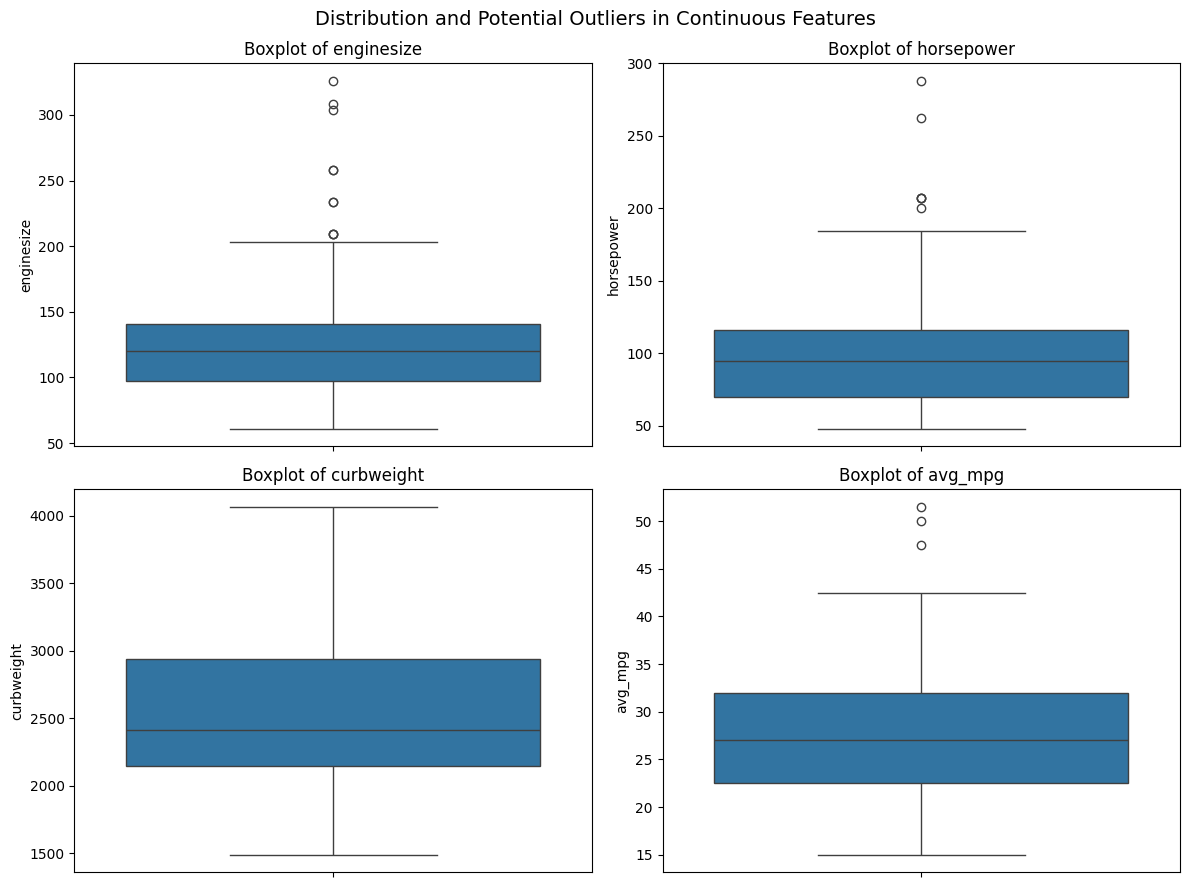

In [ ]:
# Create four boxplots in a 2 × 2 layout
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Define the features and their positions
plot_features = [
    ("enginesize", axes[0, 0]),
    ("horsepower", axes[0, 1]),
    ("curbweight", axes[1, 0]),
    ("avg_mpg", axes[1, 1])
]

# Draw each boxplot with the correct title and axis label
for feature, ax in plot_features:
    sns.boxplot(data=df, y=feature, ax=ax)
    ax.set_title(f"Boxplot of {feature}")
    ax.set_xlabel("")
    ax.set_ylabel(feature)

fig.suptitle(
    "Distribution and Potential Outliers in Continuous Features",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Outlier Identification Using the IQR Method

The interquartile range (IQR) method identifies potential outliers by examining values outside the expected range of the middle 50% of observations.

The IQR is calculated as the third quartile (Q3) minus the first quartile (Q1).

- **Lower bound:** Q1 − 1.5 × IQR
- **Upper bound:** Q3 + 1.5 × IQR

Values below the lower bound or above the upper bound are flagged as potential outliers. These thresholds identify unusual observations but do not prove that the values are errors.

In this project, the method will be applied to engine size, horsepower and average miles per gallon (`avg_mpg`). Potential outliers will be retained unless further investigation identifies a data-quality problem.

In [ ]:
# Create a separate copy for outlier analysis
outlier_df = df.copy()

# Calculate average MPG in the copy only
outlier_df["avg_mpg"] = (
    outlier_df["citympg"] + outlier_df["highwaympg"]
) / 2

# Select features for the IQR outlier audit
outlier_features = ["enginesize", "horsepower", "avg_mpg"]

# Store the results
outlier_results = []

for feature in outlier_features:
    # Calculate the first and third quartiles
    q1 = outlier_df[feature].quantile(0.25)
    q3 = outlier_df[feature].quantile(0.75)

    # Calculate the interquartile range
    iqr = q3 - q1

    # Calculate the outlier thresholds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Identify observations outside the thresholds
    outlier_mask = (
        (outlier_df[feature] < lower_bound) |
        (outlier_df[feature] > upper_bound)
    )

    outlier_count = outlier_mask.sum()

    # Record the results
    outlier_results.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": (
            outlier_count / len(outlier_df) * 100
        )
    })

# Display the summary table
iqr_outlier_summary = pd.DataFrame(outlier_results)
display(iqr_outlier_summary.round(2))

# Confirm that the original DataFrame was not changed
print("Original df contains avg_mpg:", "avg_mpg" in df.columns)
print("Analysis copy contains avg_mpg:", "avg_mpg" in outlier_df.columns)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,enginesize,97.0,141.0,44.0,31.00,207.00,10,4.88
1,horsepower,70.0,116.0,46.0,1.00,185.00,6,2.93
2,avg_mpg,22.5,32.0,9.5,8.25,46.25,3,1.46


Original df contains avg_mpg: True
Analysis copy contains avg_mpg: True


---

> **Key Findings — IQR Outlier Analysis**
>
> - **Engine size:** 10 observations (4.88%) fall outside the IQR bounds of 31 to 207.
> - **Horsepower:** 6 observations (2.93%) fall outside the bounds of 1 to 185.
> - **Average MPG:** 3 observations (1.46%) fall outside the bounds of 8.25 to 46.25.
> - **Interpretation:** These observations are potential outliers, not necessarily data errors.
> - **Handling decision:** The observations will be retained unless further investigation identifies data-quality problems.
>
> **Conclusion:** The IQR method identified a small proportion of potential outliers. These observations will be retained for subsequent analysis unless evidence indicates that they are incorrect.

## Categorical Feature Analysis

This section examines the frequency and percentage distribution of vehicle manufacturers, fuel types, body styles, and drivetrain configurations.

Understanding the distribution of these categories helps identify common and less-represented vehicle groups before investigating their relationships with car prices and preparing categorical variables for machine learning.

In [ ]:
# Select the categorical features for analysis
categorical_features = [
    "brand",
    "fueltype",
    "carbody",
    "drivewheel"
]

# Calculate frequency counts and percentages
for feature in categorical_features:

    print(f"\nFrequency Distribution: {feature}")

    # Count observations in each category
    counts = df[feature].value_counts(dropna=False)

    # Calculate percentages
    percentages = df[feature].value_counts(
        dropna=False,
        normalize=True
    ) * 100

    # Combine counts and percentages into one table
    frequency_table = pd.DataFrame({
        "Count": counts,
        "Percentage (%)": percentages.round(2)
    })

    display(frequency_table)


Frequency Distribution: brand


,Count,Percentage (%)
brand,,
toyota,32,15.61
nissan,18,8.78
mazda,17,8.29
mitsubishi,13,6.34
honda,13,6.34
volkswagen,12,5.85
subaru,12,5.85
peugeot,11,5.37
volvo,11,5.37



Frequency Distribution: fueltype


,Count,Percentage (%)
fueltype,,
gas,185,90.24
diesel,20,9.76



Frequency Distribution: carbody


,Count,Percentage (%)
carbody,,
sedan,96,46.83
hatchback,70,34.15
wagon,25,12.20
hardtop,8,3.90
convertible,6,2.93



Frequency Distribution: drivewheel


,Count,Percentage (%)
drivewheel,,
fwd,120,58.54
rwd,76,37.07
4wd,9,4.39


---

> **Key Findings — Categorical Feature Analysis**
>
> - **Fuel type:** Gas vehicles account for 90.24% of the dataset, while diesel vehicles account for 9.76%.
> - **Body style:** Sedans are the most common body type (46.83%), followed by hatchbacks (34.15%). Convertibles are the least common, with 6 vehicles (2.93%).
> - **Drivetrain:** Front-wheel-drive vehicles represent 58.54% of the dataset, while rear-wheel-drive vehicles represent 37.07%. Four-wheel-drive vehicles account for only 4.39%.
> - **Manufacturer:** Toyota is the most represented brand, with 32 vehicles (15.61%). Some manufacturers have very few observations.
>
> **Conclusion:** The dataset contains an uneven distribution of vehicle categories. This should be considered when interpreting group comparisons and evaluating model performance.

### Visualising Categorical Feature Distributions

Bar charts are used to visualise the frequency of different vehicle categories. They make it easier to compare the representation of fuel types and body styles in the dataset.

The charts below complement the frequency tables by presenting the number of vehicles in each category visually.

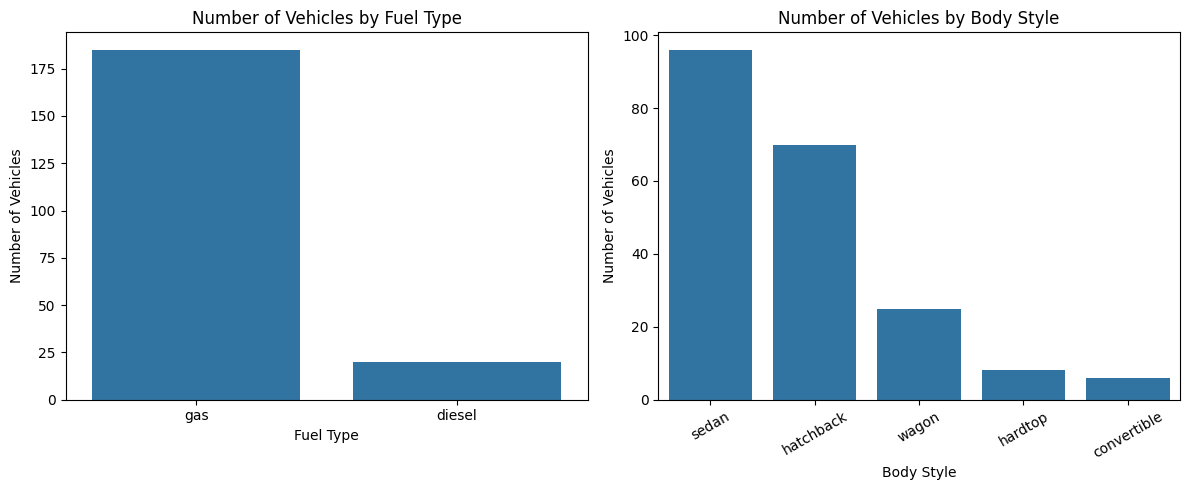

In [ ]:
# Create count plots for fuel type and body style
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="fueltype", ax=axes[0])
axes[0].set_title("Number of Vehicles by Fuel Type")
axes[0].set_xlabel("Fuel Type")
axes[0].set_ylabel("Number of Vehicles")

sns.countplot(
    data=df,
    x="carbody",
    order=df["carbody"].value_counts().index,
    ax=axes[1]
)
axes[1].set_title("Number of Vehicles by Body Style")
axes[1].set_xlabel("Body Style")
axes[1].set_ylabel("Number of Vehicles")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

---

> **Key Findings — Categorical Feature Visualisation**
>
> - **Fuel type:** Gas vehicles dominate the dataset, with 185 vehicles compared with only 20 diesel vehicles.
> - **Body style:** Sedans are the most common category (96 vehicles), followed by hatchbacks (70) and wagons (25).
> - **Less-represented categories:** Hardtops and convertibles have relatively few observations, with 8 and 6 vehicles respectively.
> - **Data imbalance:** The unequal representation of categories should be considered when comparing prices across groups and evaluating model performance.
>
> **Conclusion:** The charts show that the dataset is concentrated in gas-powered vehicles and sedan or hatchback body styles. These distributions provide useful context for the subsequent analysis of vehicle prices.

### Car Price by Drivetrain

This analysis examines how car prices vary across drivetrain categories: front-wheel drive (`fwd`), rear-wheel drive (`rwd`), and four-wheel drive (`4wd`).

Grouped descriptive statistics will be used to compare the number of vehicles, mean price, median price, and price variability within each category. A boxplot will then help visualise differences in price distributions and identify potential outliers.

The results will provide context for the subsequent hypothesis test comparing front-wheel-drive and rear-wheel-drive vehicles.

In [ ]:
# Summarise car prices by drivetrain category
drivewheel_price_summary = (
    df.groupby("drivewheel")["price"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

# Display the grouped statistics
display(drivewheel_price_summary)

,count,mean,median,std,min,max
drivewheel,,,,,,
4wd,9,11087.46,9233.0,3988.64,7603.0,17859.17
fwd,120,9239.31,8222.0,3317.93,5118.0,23875.00
rwd,76,19910.81,16912.5,9120.14,6785.0,45400.00


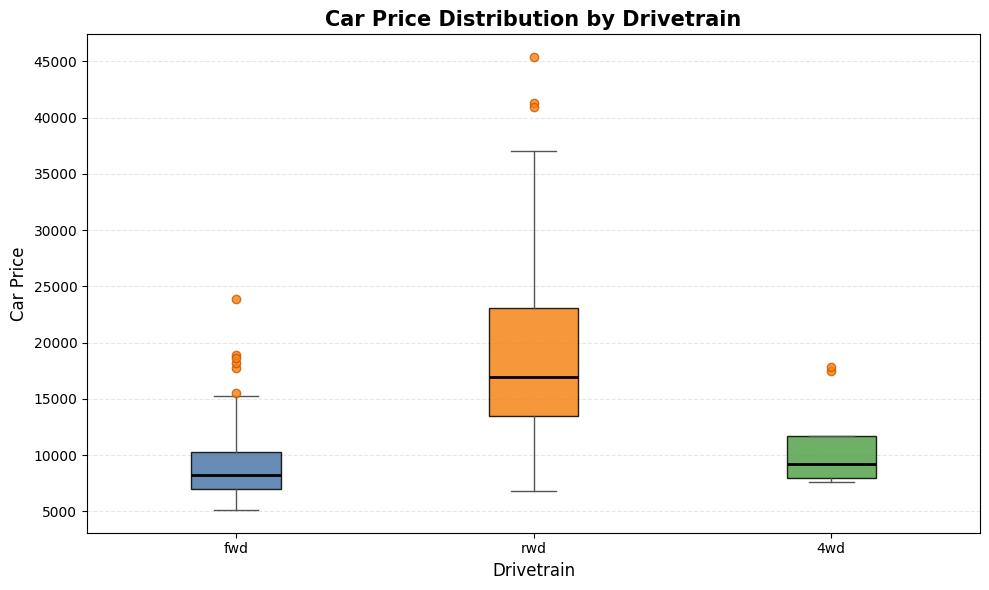

In [ ]:
# Compare car prices across drivetrain categories
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare prices for each drivetrain
drivewheel_categories = ["fwd", "rwd", "4wd"]

price_data = [
    df.loc[df["drivewheel"] == category, "price"].dropna()
    for category in drivewheel_categories
]

# Create the boxplot
boxplot = ax.boxplot(
    price_data,
    labels=drivewheel_categories,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
    whiskerprops={"color": "#555555"},
    capprops={"color": "#555555"},
    flierprops={
        "marker": "o",
        "markerfacecolor": "#FF7F0E",
        "markeredgecolor": "#C45A00",
        "alpha": 0.8
    }
)

# Apply a different colour to each drivetrain
colors = ["#4C78A8", "#F58518", "#54A24B"]

for patch, color in zip(boxplot["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

# Add titles and labels
ax.set_title(
    "Car Price Distribution by Drivetrain",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Drivetrain", fontsize=12)
ax.set_ylabel("Car Price", fontsize=12)

# Add horizontal gridlines
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

---

> **Key Findings — Car Price by Drivetrain**
>
> - **Front-wheel drive (FWD):** The boxplot shows a relatively low median price and a narrower price distribution than RWD vehicles.
> - **Rear-wheel drive (RWD):** The median price is higher, and the distribution is wider, indicating greater variability in this group.
> - **Four-wheel drive (4WD):** The group contains only nine vehicles, so its observed price distribution should be interpreted cautiously.
> - **Potential outliers:** All three groups contain unusually high prices. These observations may represent genuine vehicles and should not be removed automatically.
>
> **Conclusion:** Car prices appear to vary across drivetrain categories in this dataset. A formal hypothesis test will be used to investigate whether the mean prices of FWD and RWD vehicles differ statistically.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is used to investigate the cleaned dataset, understand the distribution of car prices, identify relationships between vehicle characteristics and price, and explore patterns that may inform business decisions.

This section uses descriptive statistics and visualisations to address the project objective of understanding the factors associated with car prices. The findings will help guide subsequent statistical analysis, hypothesis testing, and machine learning model development.

### Distribution of Car Prices

Understanding the distribution of car prices helps identify typical price ranges, variability, and potential skewness in the dataset. This analysis uses a histogram to show the frequency of prices across different ranges and a box plot to summarise the distribution and highlight potential outliers.

These visualisations will help assess whether car prices are concentrated within a particular range or whether a small number of vehicles have substantially higher prices.

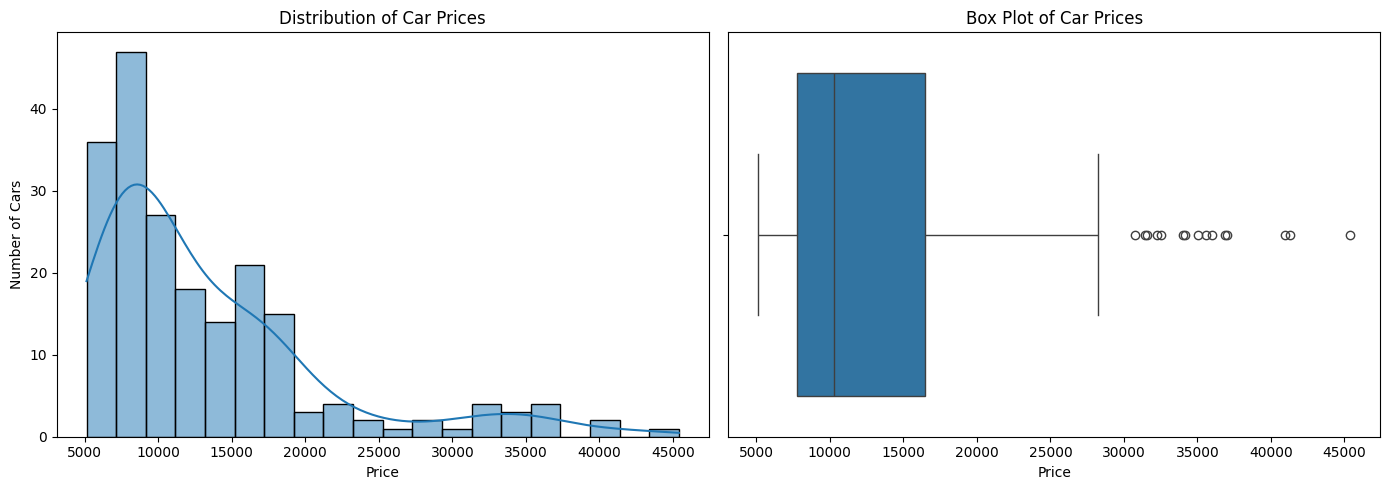

In [ ]:
# Create a figure with two plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: show the distribution of car prices
sns.histplot(data=df, x="price", bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Car Prices")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Number of Cars")

# Box plot: summarise price spread and potential outliers
sns.boxplot(data=df, x="price", ax=axes[1])
axes[1].set_title("Box Plot of Car Prices")
axes[1].set_xlabel("Price")

# Improve layout and display the plots
plt.tight_layout()
plt.show()

---

> **Key Findings — Distribution of Car Prices**
>
> - The histogram shows a **right-skewed distribution**: most cars are concentrated at lower price levels, while fewer cars have much higher prices.
> - The highest concentration of observations appears to be around the lower price ranges, particularly approximately 7,000–10,000.
> - The box plot shows a wide spread of prices and several potential high-price outliers above the upper whisker.
> - A small number of vehicles have prices above 30,000, with the maximum price appearing to be approximately 45,000.
>
> **Business implication:** The company should investigate which vehicle characteristics are associated with higher prices, as these may help explain differences in market positioning.
>
> **Note:** Potential outliers are not necessarily errors. They should be investigated alongside vehicle characteristics before any decision is made to remove or transform them.

### Average Car Price by Manufacturer

Comparing average car prices across manufacturers helps identify differences in price positioning within the dataset. A horizontal bar chart displays the average price for each manufacturer, making it easier to compare brands and identify those with higher or lower average prices.

This analysis supports the business objective of understanding pricing differences between manufacturers. However, average prices may also reflect differences in vehicle characteristics, such as engine size, horsepower, and vehicle weight. Therefore, the results will be interpreted as descriptive comparisons rather than evidence of causation.

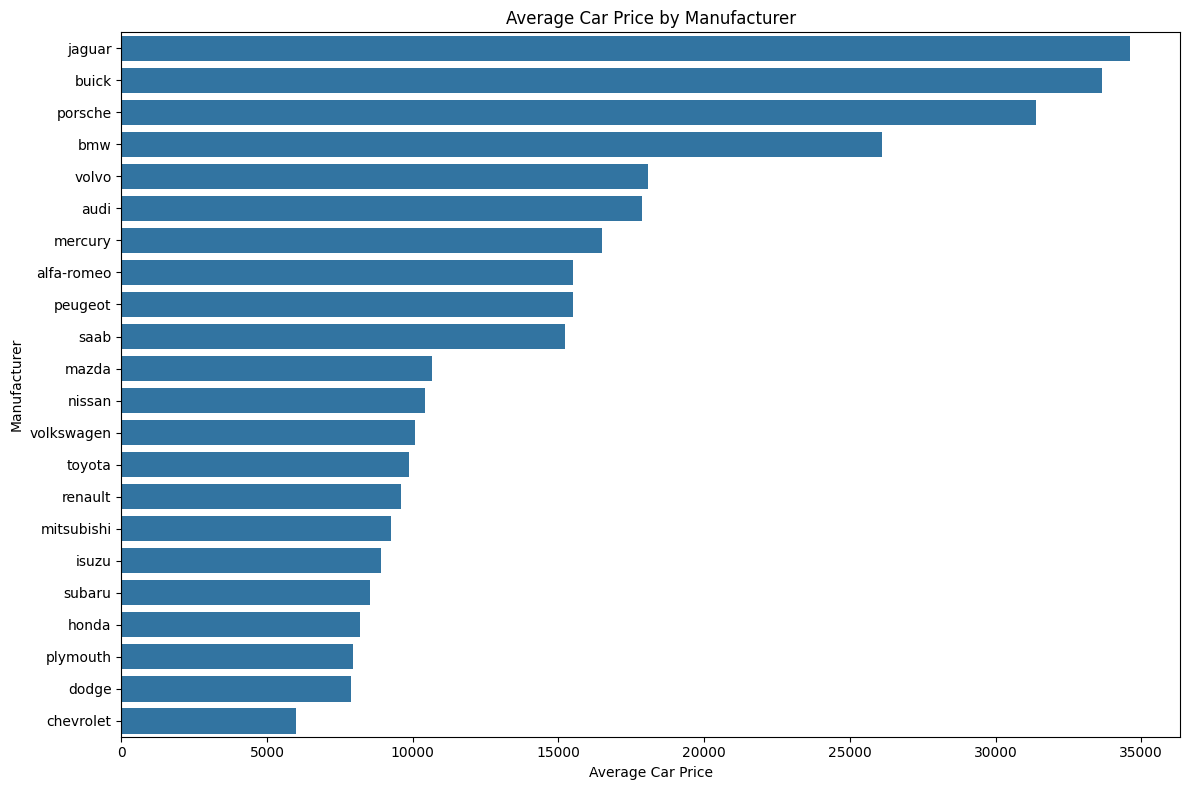

In [ ]:
# Calculate the average price for each manufacturer
avg_price_by_brand = (
    df.groupby("brand", as_index=False)["price"]
    .mean()
    .sort_values("price", ascending=False)
)

# Create a bar chart using Seaborn and Matplotlib
plt.figure(figsize=(12, 8))

sns.barplot(
    data=avg_price_by_brand,
    x="price",
    y="brand"
)

# Add titles and labels
plt.title("Average Car Price by Manufacturer")
plt.xlabel("Average Car Price")
plt.ylabel("Manufacturer")

# Format the chart
plt.tight_layout()
plt.show()

---

> **Key Findings — Average Car Price by Manufacturer**
>
> - **Highest average prices:** Jaguar has the highest average price at approximately 34,500, followed by Buick at around 33,700 and Porsche at around 31,400.
> - **Other high-priced manufacturers:** BMW has an average price of approximately 26,100, while Volvo and Audi are both around 18,000.
> - **Lowest average prices:** Chevrolet has the lowest average price at approximately 6,000, followed by Dodge and Plymouth at around 7,800.
> - **Differences between manufacturers:** The substantial variation in average prices suggests that the dataset contains vehicles positioned across different price segments.
>
> **Business implication:** These comparisons can help identify potential competitor groups and price segments. Further analysis of engine size, horsepower, vehicle weight and other characteristics is needed to understand these differences.
>
> **Limitation:** These are descriptive averages for the vehicles in this dataset. They do not establish that manufacturer identity causes a particular price.

### Relationship Between Engine Size and Car Price

Engine size is a vehicle characteristic that may be associated with its price. A scatter plot allows us to examine how car prices vary with engine size and identify possible patterns, clusters, and unusual observations.

This analysis supports the business objective of understanding which vehicle characteristics are associated with price differences. However, other factors, including horsepower, vehicle weight, and manufacturer, may also influence prices. The results will therefore be interpreted as associations rather than evidence of causation.

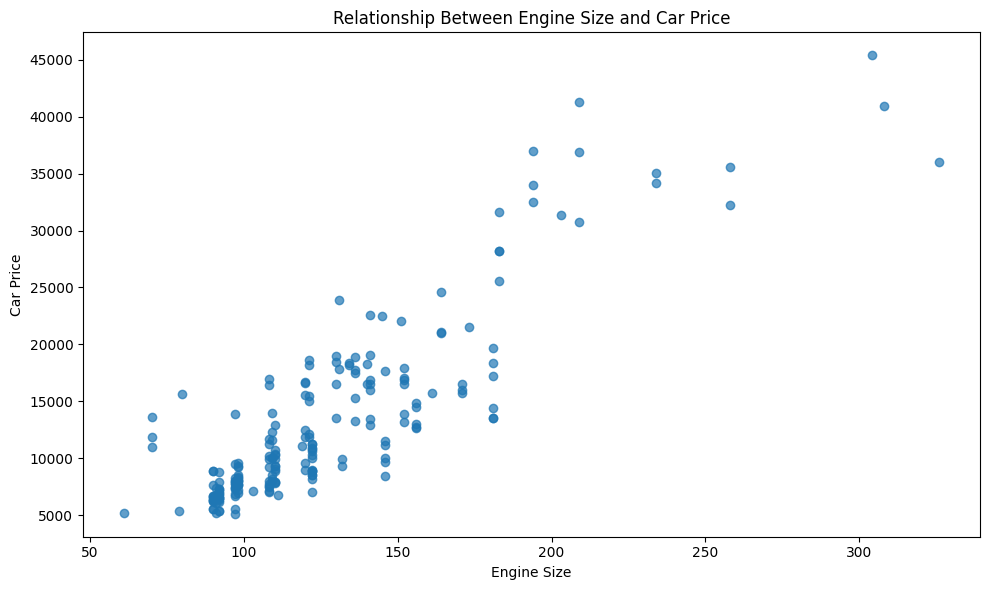

In [ ]:
# Create a scatter plot of engine size against car price
plt.figure(figsize=(10, 6))

plt.scatter(
    df["enginesize"],
    df["price"],
    alpha=0.7
)

# Add the chart title and axis labels
plt.title("Relationship Between Engine Size and Car Price")
plt.xlabel("Engine Size")
plt.ylabel("Car Price")

# Improve the chart layout
plt.tight_layout()
plt.show()

---

> **Key Findings — Relationship Between Engine Size and Car Price**
>
> - **Overall relationship:** The scatter plot shows [describe whether prices generally increase as engine size increases].
> - **Price variation:** Vehicles with similar engine sizes can have different prices, suggesting that other characteristics may also be important.
> - **Potential outliers:** [Describe any vehicles or observations that appear unusually expensive or inexpensive, if visible.]
>
> **Business implication:** Engine size may help explain differences in car prices and could be a useful feature in a price prediction model. Other variables, such as horsepower, vehicle weight, and manufacturer, should also be investigated.
>
> **Limitation:** The scatter plot shows an association between engine size and price; it does not demonstrate that engine size alone causes price differences.

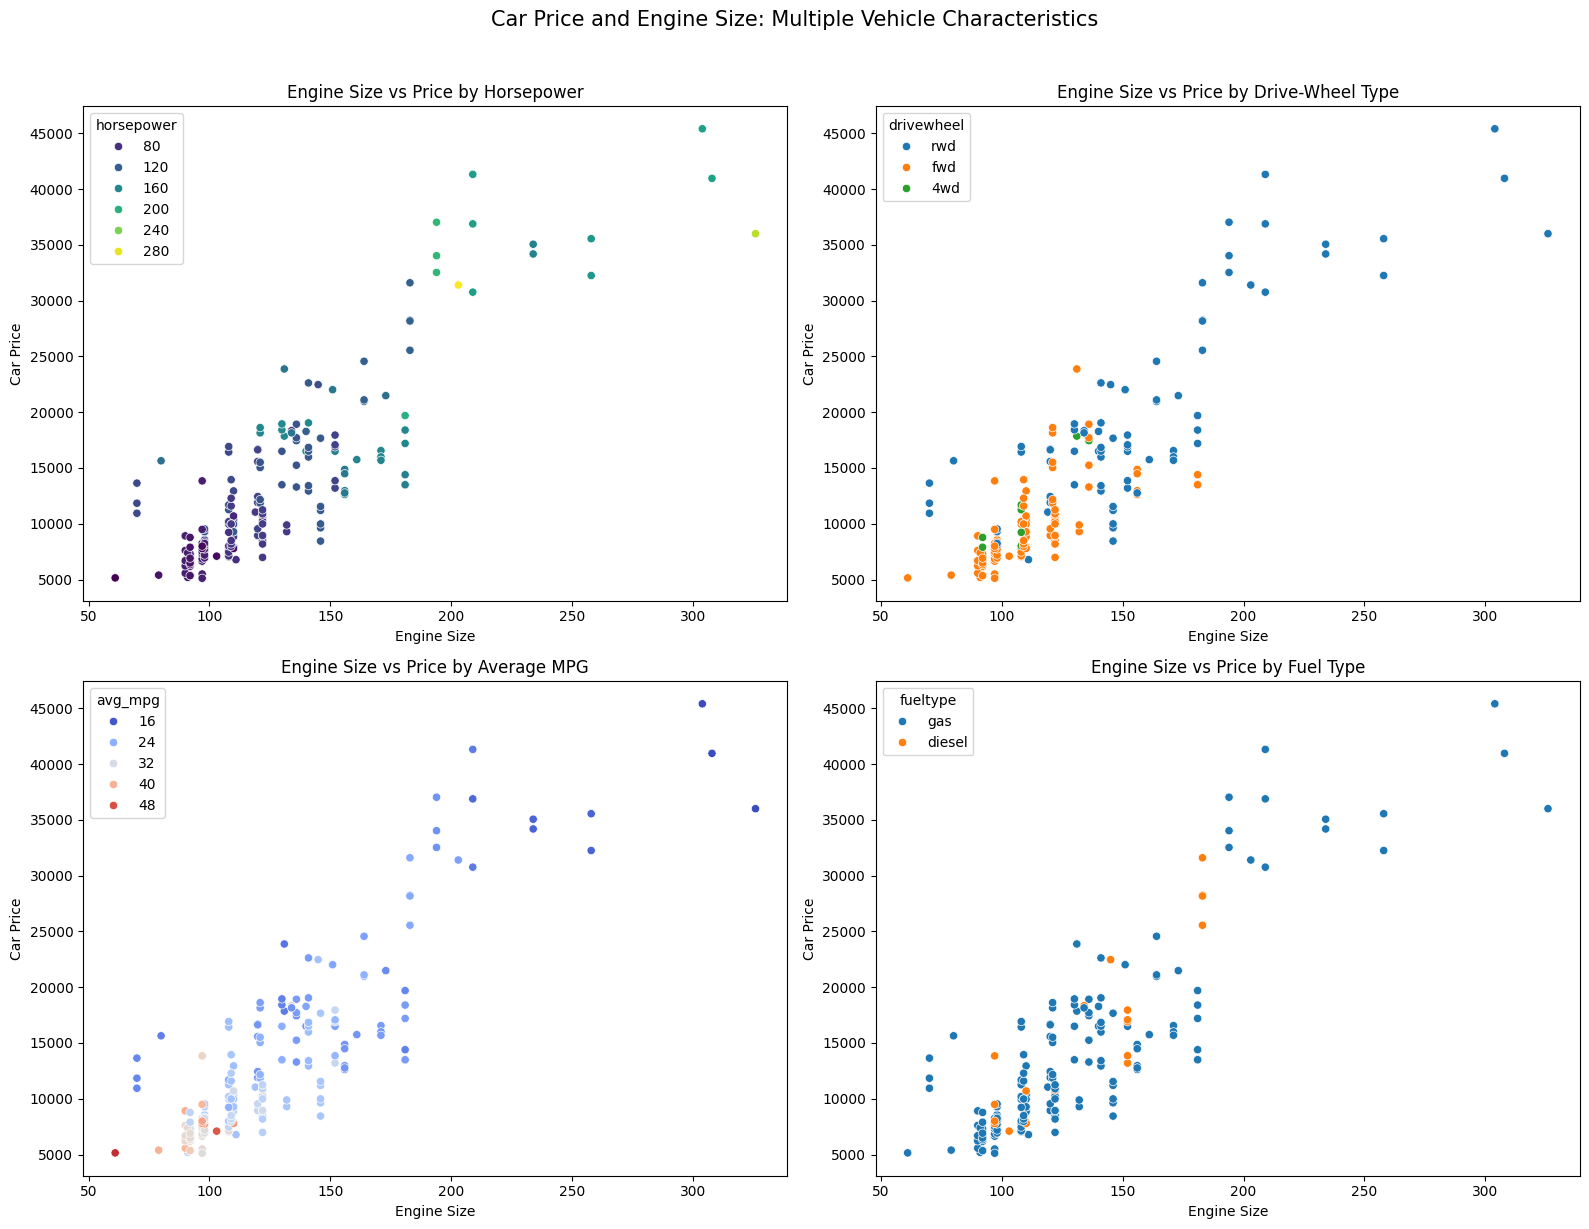

In [ ]:
# Create four scatter plots to explore car prices
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Colour by horsepower
sns.scatterplot(
    data=df,
    x="enginesize",
    y="price",
    hue="horsepower",
    palette="viridis",
    ax=axes[0, 0],
    legend="brief"
)
axes[0, 0].set_title("Engine Size vs Price by Horsepower")

# 2. Colour by drive-wheel type
sns.scatterplot(
    data=df,
    x="enginesize",
    y="price",
    hue="drivewheel",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Engine Size vs Price by Drive-Wheel Type")

# 3. Colour by average fuel economy
sns.scatterplot(
    data=df,
    x="enginesize",
    y="price",
    hue="avg_mpg",
    palette="coolwarm",
    ax=axes[1, 0],
    legend="brief"
)
axes[1, 0].set_title("Engine Size vs Price by Average MPG")

# 4. Colour by fuel type
sns.scatterplot(
    data=df,
    x="enginesize",
    y="price",
    hue="fueltype",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Engine Size vs Price by Fuel Type")

# Add axis labels to all four plots
for ax in axes.flat:
    ax.set_xlabel("Engine Size")
    ax.set_ylabel("Car Price")

# Add an overall title and prevent title overlap
fig.suptitle(
    "Car Price and Engine Size: Multiple Vehicle Characteristics",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

---

> **Key Findings — Engine Size, Car Price and Vehicle Characteristics**
>
> - **Engine size and price:** The plots show a positive association between engine size and car price. Vehicles with larger engines generally have higher prices, although there is variation between individual cars.
>
> - **Horsepower:** Higher-priced vehicles often have higher horsepower values. This suggests that horsepower may be a useful predictor of car price, although it may overlap with engine size.
>
> - **Drive-wheel type:** Rear-wheel-drive vehicles (`rwd`) appear among many of the higher-priced cars, while front-wheel-drive vehicles (`fwd`) are concentrated more heavily in the lower-to-middle price ranges. Four-wheel-drive vehicles (`4wd`) are relatively few in this dataset.
>
> - **Fuel economy:** Higher average MPG values are generally more common among vehicles with smaller engines and lower prices. This suggests a potential relationship between fuel economy, engine size and price.
>
> - **Fuel type:** Most observations are petrol (`gas`) vehicles, with fewer diesel vehicles. The limited number of diesel observations makes comparisons between fuel types less conclusive.
>
> **Business implication:** Engine size, horsepower, drive-wheel type and fuel economy are potential features for further investigation in the car price prediction model.
>
> **Limitation:** These plots show associations, not causation. The relationships should be examined alongside numerical summaries and model evaluation before drawing stronger conclusions.

### Correlation Analysis of Numerical Variables

Correlation analysis measures the strength and direction of linear relationships between numerical variables. A correlation heatmap presents these relationships visually, making it easier to identify variables associated with car price and potential relationships between predictor features.

This analysis will help identify candidate features for the car price prediction model and highlight possible multicollinearity between predictors. Correlation does not establish causation, and a weak linear correlation does not necessarily mean that two variables have no relationship.

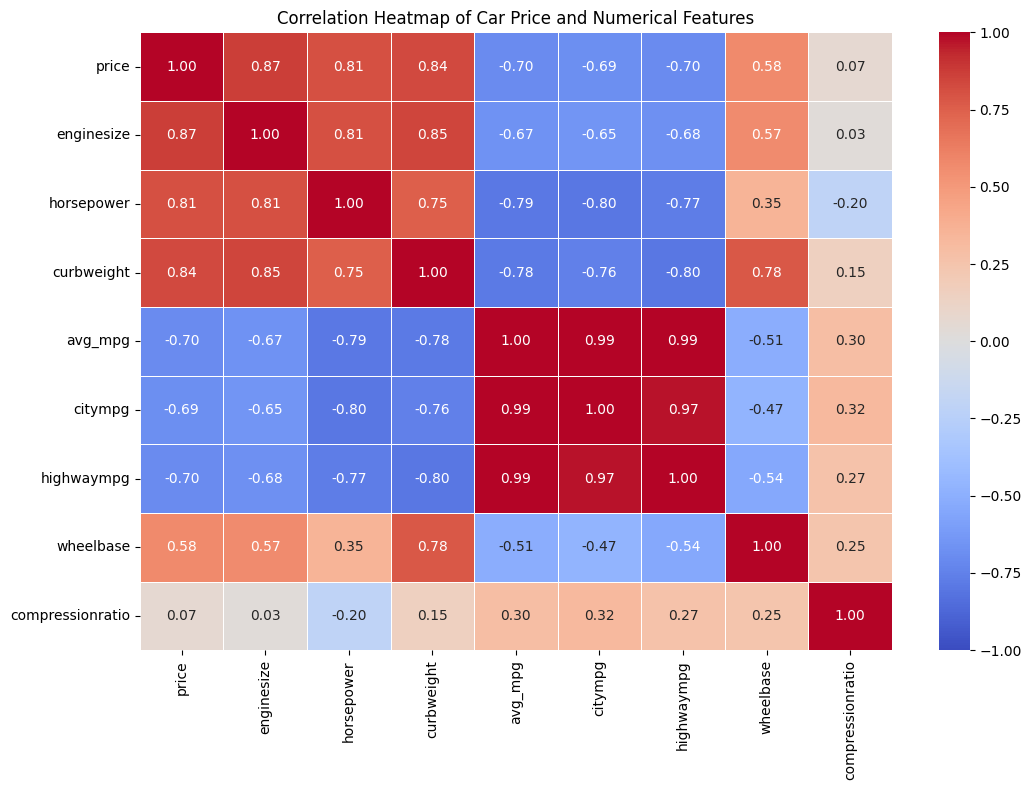

In [ ]:
# Select numerical variables relevant to car price analysis
correlation_columns = [
    "price",
    "enginesize",
    "horsepower",
    "curbweight",
    "avg_mpg",
    "citympg",
    "highwaympg",
    "wheelbase",
    "compressionratio"
]

# Calculate the correlation matrix
correlation_matrix = df[correlation_columns].corr()

# Create the correlation heatmap
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5
)

# Add the chart title
plt.title("Correlation Heatmap of Car Price and Numerical Features")
plt.tight_layout()
plt.show()

---

> **Key Findings — Correlation Analysis**
>
> - **Engine size and price:** Engine size has a strong positive correlation with price (**r = 0.87**). In this dataset, cars with larger engines tend to have higher prices.
>
> - **Horsepower and price:** Horsepower also has a strong positive correlation with price (**r = 0.81**), suggesting that engine power may be a useful feature for predicting car prices.
>
> - **Vehicle weight and price:** Curb weight has a strong positive correlation with price (**r = 0.84**). Heavier vehicles tend to be more expensive in this dataset.
>
> - **Fuel economy and price:** Average MPG has a negative correlation with price (**r = -0.70**). Vehicles with better fuel economy tend to have lower prices in this dataset, although other vehicle characteristics may contribute to this pattern.
>
> - **Relationships between predictors:** Engine size and curb weight are strongly correlated (**r = 0.85**), while average MPG is very strongly correlated with city MPG and highway MPG (**r = 0.99** for both). These relationships indicate overlapping information between some features.
>
> - **Compression ratio:** Its correlation with price is weak (**r = 0.07**), indicating little linear association with price in this dataset.
>
> **Business implication:** Engine size, horsepower and curb weight are promising candidate predictors for the price model. Their overlapping information should be considered during feature selection and model evaluation.
>
> **Limitation:** Correlation measures linear association, not causation. A weak correlation does not necessarily mean a feature has no predictive value, and the observed relationships may be influenced by other variables.

---

## EDA Conclusion

The exploratory data analysis examined the distribution of car prices, numerical vehicle characteristics, categorical feature frequencies, potential outliers, and relationships between variables.

The main findings are:

- **Price distribution:** Car prices are right-skewed, with substantial variation between lower-priced and higher-priced vehicles.
- **Important relationships:** Engine size, horsepower, and curb weight show strong positive correlations with price in this dataset.
- **Categorical distributions:** Manufacturers, fuel types, body styles, and drivetrain categories are unevenly represented.
- **Potential outliers:** The IQR method identified observations outside the expected ranges for engine size, horsepower, and average MPG. These observations have been retained pending further investigation.
- **Overlapping features:** Average MPG is strongly correlated with city and highway MPG because it is derived from these variables. This overlap should be considered during feature selection.

**Conclusion:** EDA has identified useful patterns and potential predictors for further analysis. However, correlations alone do not establish causation or statistical significance. The next stages will use statistical testing and predictive modelling to investigate price differences and evaluate how accurately car prices can be estimated.

## Hypothesis Testing

Hypothesis testing uses statistical methods to assess whether an observed difference in a sample provides sufficient evidence of a difference between groups.

This section investigates whether mean car prices differ between front-wheel-drive (FWD) and rear-wheel-drive (RWD) vehicles in the dataset.

### Research Question

Is there a statistically significant difference in mean car prices between FWD and RWD vehicles?

### Hypotheses

- **Null hypothesis (H₀):** The population mean car prices for FWD and RWD vehicles are equal.
- **Alternative hypothesis (H₁):** The population mean car prices for FWD and RWD vehicles are different.

### Significance Level

The significance level is set at **α = 0.05**.

The analysis will examine group sizes and price distributions before selecting a suitable statistical test. A statistically significant result would indicate evidence of a difference in mean prices, but would not establish that drivetrain type causes the difference.

In [ ]:
# Select front-wheel-drive and rear-wheel-drive vehicles
drive_groups = df[
    df["drivewheel"].isin(["fwd", "rwd"])
].copy()

# Calculate descriptive statistics for car prices in each group
drive_price_summary = (
    drive_groups.groupby("drivewheel")["price"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

# Display the results
display(drive_price_summary)

,count,mean,median,std,min,max
drivewheel,,,,,,
fwd,120,9239.31,8222.0,3317.93,5118.0,23875.0
rwd,76,19910.81,16912.5,9120.14,6785.0,45400.0


### Welch's Independent-Samples t-Test

Welch's independent-samples t-test is used to assess whether the population mean prices of two independent groups differ significantly. Unlike the standard Student's t-test, Welch's test does not assume equal population variances.

In this analysis, we compare the prices of front-wheel-drive (`fwd`) and rear-wheel-drive (`rwd`) vehicles.

- **Null hypothesis (H₀):** The population mean prices of FWD and RWD vehicles are equal.
- **Alternative hypothesis (H₁):** The population mean prices of FWD and RWD vehicles are different.
- **Significance level (α):** 0.05.

The p-value will be compared with the significance level to determine whether the null hypothesis should be rejected. The test assesses evidence of a difference in mean prices; it does not establish causation.

In [ ]:
# Import the statistical test
from scipy.stats import ttest_ind

# Extract prices for each drivetrain group
fwd_prices = df.loc[df["drivewheel"] == "fwd", "price"]
rwd_prices = df.loc[df["drivewheel"] == "rwd", "price"]

# Perform Welch's independent-samples t-test
t_statistic, p_value = ttest_ind(
    fwd_prices,
    rwd_prices,
    equal_var=False,
    alternative="two-sided"
)

# Display the results
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.6f}")

# Compare the p-value with the significance level
alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print("Conclusion: There is evidence of a difference in mean prices.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("Conclusion: There is insufficient evidence of a difference in mean prices.")

T-statistic: -9.7983
P-value: 0.000000
Decision: Reject the null hypothesis.
Conclusion: There is evidence of a difference in mean prices.


---

> **Key Findings — Welch's Independent-Samples t-Test**
>
> - **Test statistic:** The calculated t-statistic is -9.7983.
> - **P-value:** The p-value is below 0.05 and is displayed as 0.000000 when rounded to six decimal places.
> - **Decision:** Reject the null hypothesis.
> - **Interpretation:** There is statistically significant evidence that mean car prices differ between front-wheel-drive (FWD) and rear-wheel-drive (RWD) vehicles in this dataset.
> - **Direction of the difference:** The sample mean price for RWD vehicles (19,910.81) is higher than the sample mean for FWD vehicles (9,239.31).
>
> **Conclusion:** The results provide strong evidence of a difference in mean prices between the two drivetrain groups. This is an association in the observed dataset and does not establish that drivetrain type causes higher prices.

### Confidence Interval and Effect of the Difference

The p-value helps assess statistical significance, while a confidence interval estimates the plausible range for the difference between the population mean prices of RWD and FWD vehicles.

A 95% confidence interval will be calculated for the difference in mean prices (RWD minus FWD). If the interval does not include zero, this is consistent with a statistically significant difference at the 5% level for a two-sided test.

The exact p-value will also be displayed in scientific notation to avoid rounding a very small value to zero.

In [ ]:
# Import the required functions
from scipy.stats import ttest_ind
from math import sqrt

# Perform Welch's t-test and retain the full result
test_result = ttest_ind(
    fwd_prices,
    rwd_prices,
    equal_var=False,
    alternative="two-sided"
)

# Calculate the difference in sample means (RWD minus FWD)
mean_difference = rwd_prices.mean() - fwd_prices.mean()

# Calculate the standard error for Welch's test
n_fwd = len(fwd_prices)
n_rwd = len(rwd_prices)

var_fwd = fwd_prices.var(ddof=1)
var_rwd = rwd_prices.var(ddof=1)

standard_error = sqrt(
    var_fwd / n_fwd + var_rwd / n_rwd
)

# Calculate Welch-Satterthwaite degrees of freedom
degrees_freedom = (
    (var_fwd / n_fwd + var_rwd / n_rwd) ** 2
    / (
        (var_fwd / n_fwd) ** 2 / (n_fwd - 1)
        + (var_rwd / n_rwd) ** 2 / (n_rwd - 1)
    )
)

# Calculate the 95% confidence interval
from scipy.stats import t

critical_value = t.ppf(0.975, degrees_freedom)

lower_bound = mean_difference - critical_value * standard_error
upper_bound = mean_difference + critical_value * standard_error

# Display the results
print(f"Mean price difference (RWD - FWD): {mean_difference:.2f}")
print(f"T-statistic: {test_result.statistic:.4f}")
print(f"Exact p-value: {test_result.pvalue:.6e}")
print(f"Degrees of freedom: {degrees_freedom:.2f}")
print(f"95% confidence interval: ({lower_bound:.2f}, {upper_bound:.2f})")

Mean price difference (RWD - FWD): 10671.50
T-statistic: -9.7983
Exact p-value: 9.634370e-16
Degrees of freedom: 87.71
95% confidence interval: (8507.01, 12835.99)


---

> **Key Findings — Welch's t-Test and Confidence Interval**
>
> - **Mean price difference:** RWD vehicles have a sample mean price 10,671.50 price units higher than FWD vehicles.
> - **Test statistic:** Welch's t-statistic is -9.7983, with approximately 87.71 degrees of freedom.
> - **P-value:** The exact p-value is approximately 9.63 × 10⁻¹⁶, which is substantially below the significance level of 0.05.
> - **Decision:** Reject the null hypothesis.
> - **95% confidence interval:** The estimated difference in population mean prices (RWD minus FWD) ranges from 8,507.01 to 12,835.99. The interval excludes zero.
>
> **Conclusion:** The results provide strong statistical evidence of a difference in mean prices between FWD and RWD vehicles. In this dataset, RWD vehicles have higher average prices. However, this observational comparison does not establish that drivetrain type causes higher prices; other characteristics, such as engine size, horsepower, and vehicle brand, may also contribute.

## Pearson Correlation Hypothesis Tests

The Welch t-test examines differences in mean car prices between drivetrain groups. Pearson correlation tests will complement this analysis by examining whether car price has a statistically significant linear relationship with selected numerical vehicle characteristics.

For each selected feature:

- **Null hypothesis (H₀):** The population Pearson correlation between the feature and car price is zero (ρ = 0).
- **Alternative hypothesis (H₁):** The population Pearson correlation is not zero (ρ ≠ 0).

The significance level is set at α = 0.05. Pearson's correlation coefficient (r) measures the direction and strength of the linear relationship, while the p-value assesses the evidence against the null hypothesis.

These tests identify statistical associations, not causal relationships. Their assumptions and the possibility of multiple-testing effects will also be considered.

In [ ]:
from scipy.stats import pearsonr
import pandas as pd

# Select numerical features to test against car price
features = ["enginesize", "horsepower", "curbweight", "avg_mpg"]

results = []

# Calculate Pearson correlation and p-value for each feature
for feature in features:
    r, p_value = pearsonr(df[feature], df["price"])

    results.append({
        "Feature": feature,
        "Pearson correlation (r)": r,
        "p-value": p_value,
        "Significant at 0.05": p_value < 0.05
    })

# Display the results in a table
correlation_tests = pd.DataFrame(results)
correlation_tests.round(4)

,Feature,Pearson correlation (r),p-value,Significant at 0.05
0,enginesize,0.8741,0.0,True
1,horsepower,0.8081,0.0,True
2,curbweight,0.8353,0.0,True
3,avg_mpg,-0.6968,0.0,True


In [ ]:
# Display p-values in scientific notation
correlation_tests.style.format({
    "Pearson correlation (r)": "{:.4f}",
    "p-value": "{:.3e}"
})

,Feature,Pearson correlation (r),p-value,Significant at 0.05
0,enginesize,0.8741,1.355e-65,True
1,horsepower,0.8081,1.483e-48,True
2,curbweight,0.8353,1.214e-54,True
3,avg_mpg,-0.6968,3.992e-31,True


> **Key findings**
>
> All four features show statistically significant linear correlations with car price at the 5% significance level (p < 0.05).
>
> - **Engine size:** Strong positive correlation (r = 0.8741).
> - **Horsepower:** Strong positive correlation (r = 0.8081).
> - **Curb weight:** Strong positive correlation (r = 0.8353).
> - **Average MPG:** Strong negative correlation (r = -0.6968).
>
> **Conclusion:** Engine size has the strongest observed linear correlation with price among these four features. These relationships do not establish causation.

### Multiple-Testing Correction: Holm Method

Four Pearson correlation tests were conducted to investigate the relationships between car price and selected numerical vehicle characteristics. To account for multiple hypothesis testing, the Holm correction is applied to control the family-wise error rate at a significance level of α = 0.05.

The adjusted p-values will be used to determine whether each correlation remains statistically significant after the correction.

In [ ]:
from statsmodels.stats.multitest import multipletests

# Apply Holm correction to the four correlation tests
correlation_tests["Holm-adjusted p-value"] = multipletests(
    correlation_tests["p-value"],
    alpha=0.05,
    method="holm"
)[1]

correlation_tests["Significant after Holm correction"] = (
    correlation_tests["Holm-adjusted p-value"] < 0.05
)

# Display the updated results
correlation_tests.style.format({
    "Pearson correlation (r)": "{:.4f}",
    "p-value": "{:.3e}",
    "Holm-adjusted p-value": "{:.3e}"
})

,Feature,Pearson correlation (r),p-value,Significant at 0.05,Holm-adjusted p-value,Significant after Holm correction
0,enginesize,0.8741,1.355e-65,True,5.419e-65,True
1,horsepower,0.8081,1.483e-48,True,2.967e-48,True
2,curbweight,0.8353,1.214e-54,True,3.643e-54,True
3,avg_mpg,-0.6968,3.992e-31,True,3.992e-31,True


> **Key Findings**
>
> All four vehicle characteristics show statistically significant correlations with car price after the Holm correction (adjusted p < 0.05).
>
> - **Engine size:** Strongest positive correlation (r = 0.8741).
> - **Curb weight:** Strong positive correlation (r = 0.8353).
> - **Horsepower:** Strong positive correlation (r = 0.8081).
> - **Average MPG:** Strong negative correlation (r = -0.6968).
>
> **Conclusion:** Engine size has the strongest observed linear correlation with car price among the four features tested.
>
> **Limitation:** These results show associations, not causation. The vehicle characteristics may be related to one another, so their individual correlations should be interpreted with care.

## Welch's ANOVA: Comparing Prices Across Categories

Welch's Analysis of Variance (ANOVA) is used to investigate whether mean car prices differ across body style, fuel type, and drivetrain categories. It is appropriate when group variances are unequal.

**Null hypothesis (H₀):** The population mean car prices are equal across all groups for the selected categorical feature.

**Alternative hypothesis (H₁):** At least one population group mean differs.

The significance level is set at α = 0.05. P-values are adjusted using the Holm method to account for multiple comparisons.

A statistically significant result suggests that at least one group mean differs, but it does not identify which specific groups differ. These observational results do not establish causation.

### Checking the Equal-Variance Assumption

Levene's test, using the median, checks whether the group variances are equal.

- **Null hypothesis (H₀):** The group variances are equal.
- **Alternative hypothesis (H₁):** At least one group has a different variance.
- **Significance level:** α = 0.05.

If p < 0.05, there is evidence that the equal-variance assumption may be violated. Welch's ANOVA is therefore used to compare mean prices because it does not require equal group variances.

In [ ]:
from scipy.stats import levene
import pandas as pd

# Categorical features to check
categorical_features = ["carbody", "fueltype", "drivewheel"]

variance_results = []

for feature in categorical_features:
    # Separate car prices into groups
    groups = [
        group["price"].to_numpy()
        for _, group in df[[feature, "price"]].dropna().groupby(feature)
    ]

    # Test whether group variances are equal
    statistic, p_value = levene(*groups, center="median")

    variance_results.append({
        "Feature": feature,
        "Levene statistic": statistic,
        "p-value": p_value,
        "Variance assumption": (
            "Not rejected" if p_value >= 0.05
            else "Potentially violated"
        )
    })

# Display results
variance_results = pd.DataFrame(variance_results)

variance_results.style.format({
    "Levene statistic": "{:.3f}",
    "p-value": "{:.3e}"
})

,Feature,Levene statistic,p-value,Variance assumption
0,carbody,6.486,6.299e-05,Potentially violated
1,fueltype,0.306,5.810e-01,Not rejected
2,drivewheel,19.603,1.657e-08,Potentially violated


### Welch's ANOVA: Comparing Group Means

Levene's test indicated that the equal-variance assumption may be violated for body style and drivetrain. Therefore, Welch's ANOVA is used to compare mean car prices across the categories of body style, fuel type, and drivetrain.

Welch's ANOVA is more robust than classical one-way ANOVA when group variances are unequal. The significance level is α = 0.05.

- **Null hypothesis (H₀):** All population group means are equal.
- **Alternative hypothesis (H₁):** At least one population group mean differs.

The p-values will be adjusted using the Holm method to account for the three comparisons.

In [ ]:
from statsmodels.stats.oneway import anova_oneway
from statsmodels.stats.multitest import multipletests
import pandas as pd

categorical_features = ["carbody", "fueltype", "drivewheel"]
welch_results = []

for feature in categorical_features:
    groups = [
        group["price"].dropna().to_numpy()
        for _, group in df[[feature, "price"]]
        .dropna()
        .groupby(feature)
        if len(group) >= 2
    ]

    result = anova_oneway(
        data=[group for group in groups],
        use_var="unequal"
    )

    welch_results.append({
        "Feature": feature,
        "Welch F-statistic": result.statistic,
        "p-value": result.pvalue
    })

welch_results = pd.DataFrame(welch_results)

welch_results["Holm-adjusted p-value"] = multipletests(
    welch_results["p-value"],
    alpha=0.05,
    method="holm"
)[1]

welch_results["Significant at 0.05"] = (
    welch_results["Holm-adjusted p-value"] < 0.05
)

welch_results.style.format({
    "Welch F-statistic": "{:.3f}",
    "p-value": "{:.3e}",
    "Holm-adjusted p-value": "{:.3e}"
})

,Feature,Welch F-statistic,p-value,Holm-adjusted p-value,Significant at 0.05
0,carbody,5.427,3.560e-03,7.119e-03,True
1,fueltype,2.401,1.346e-01,1.346e-01,False
2,drivewheel,46.818,1.621e-08,4.863e-08,True



## Machine Learning: Car Price Prediction

### Objective

The objective of this stage is to develop a machine learning model that predicts car prices using vehicle characteristics. The model will learn relationships between features such as engine size, horsepower, curb weight, and fuel economy and the target variable, `price`.

A Linear Regression model will be used as the initial model because it provides an interpretable baseline for understanding how numerical vehicle characteristics relate to car prices.

The dataset will be prepared for modelling, divided into training and testing sets, and evaluated using appropriate regression metrics. The results will help assess how accurately the model predicts car prices for unseen vehicles.



###  Inspect the Dataset

Before building the machine learning model, the dataset will be inspected to confirm its dimensions, available features, and target variable. This step helps ensure that the data is suitable for predictive modelling.


In [68]:

# Inspect the dataset before preparing it for machine learning

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst five rows:")
display(df.head())

print("\nTarget variable summary:")
display(df["price"].describe())


Dataset shape: (205, 31)

Column names:
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price', 'brand', 'car_model', 'price_per_hp', 'power_to_weight', 'avg_mpg']

First five rows:


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,horsepower,peakrpm,citympg,highwaympg,price,brand,car_model,price_per_hp,power_to_weight,avg_mpg
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,111,5000,21,27,13495.0,alfa-romeo,giulia,121.576577,0.043564,24.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,111,5000,21,27,16500.0,alfa-romeo,stelvio,148.648649,0.043564,24.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,154,5000,19,26,16500.0,alfa-romeo,quadrifoglio,107.142857,0.054552,22.5
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,102,5500,24,30,13950.0,audi,100ls,136.764706,0.043646,27.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,115,5500,18,22,17450.0,audi,100ls,151.739130,0.040722,20.0



Target variable summary:


count      205.000000
mean     13276.710571
std       7988.852332
min       5118.000000
25%       7788.000000
50%      10295.000000
75%      16503.000000
max      45400.000000
Name: price, dtype: float64

In [69]:
# Check the derived features and target variable
derived_features = [
    "brand",
    "car_model",
    "price_per_hp",
    "power_to_weight",
    "avg_mpg",
    "price"
]

for col in derived_features:
    print(f"{col}: {'Present' if col in model_df.columns else 'Not present'}")

NameError: name 'model_df' is not defined

In [ ]:
%matplotlib inline


### Feature Selection and Target Variable

The target variable for this model is `price`, which represents the car price we want to predict.

Predictor variables will describe vehicle characteristics that may help explain differences in price. The `car_ID` column will be excluded because it is an identifier rather than a meaningful vehicle characteristic.

The original `CarName` column will also be excluded initially because it contains text. The cleaned `brand` feature can be considered instead if it is available in the current dataset.

Categorical variables will be encoded before modelling, and the data will be split into training and testing sets to evaluate performance on unseen observations.



###  Inspect Available Features

Before selecting the predictor variables for the Linear Regression model, the dataset will be inspected to understand its structure and quality.

The following checks will be performed:

- **Dataset dimensions:** Identify the number of rows and columns.
- **Data types:** Determine which variables are numerical and which are categorical.
- **Missing values:** Check whether any columns contain missing observations.

These checks will help guide feature selection and data preparation. Identifier columns such as `car_ID` will be excluded from the model predictors, and any features derived from the target variable `price` will be excluded to prevent data leakage.

The original dataset will remain unchanged during this inspection.


In [ ]:

# Inspect available columns and data types
print("Dataset shape:", df.shape)

display(
    df.dtypes.to_frame(name="Data type")
)

print("\nMissing values per column:")
display(df.isnull().sum().to_frame(name="Missing values"))


Dataset shape: (205, 31)


,Data type
car_ID,int64
symboling,int64
CarName,object
fueltype,object
aspiration,object
doornumber,object
carbody,object
drivewheel,object
enginelocation,object
wheelbase,float64



Missing values per column:


,Missing values
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0



**Key Findings:** The dataset contains 205 rows and 31 columns, with no missing values. Numerical and categorical features are available for model development. However, the identifier and target-derived features must be excluded from the predictors to prevent misleading results and data leakage.


---


###  Prepare the Modelling Dataset

A separate copy of the dataset, `model_df`, is created for machine learning to preserve the original data.

The identifier column `car_ID` is excluded because it does not represent a meaningful vehicle characteristic. The target-derived feature `price_per_hp` is also excluded to prevent data leakage.

Other potentially useful features, including `brand`, `car_model`, `power_to_weight`, and `avg_mpg`, are retained for consideration during feature selection. Additional columns will be excluded later when defining the predictors for the model.


In [72]:

# Create a separate copy for machine learning
model_df = df.copy()

# Exclude identifier and target-derived columns if present
columns_to_drop = ["car_ID", "price_per_hp"]
model_df = model_df.drop(
    columns=[col for col in columns_to_drop if col in model_df.columns]
)

# Confirm the result
print("Original dataset shape:", df.shape)
print("Modelling dataset shape:", model_df.shape)

print("\nRemaining columns:")
print(model_df.columns.tolist())


Original dataset shape: (205, 31)
Modelling dataset shape: (205, 29)

Remaining columns:
['symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price', 'brand', 'car_model', 'power_to_weight', 'avg_mpg']



**Key Findings:** The modelling dataset contains 205 rows and 29 columns after removing `car_ID` and `price_per_hp`. The original dataset remains unchanged, while other potentially useful features are retained for the next stage of feature selection.



###  Final Feature Selection

The target variable `price` will be separated from the predictor variables. The predictors will exclude `car_ID`, `CarName`, and `price_per_hp` to avoid using identifiers, raw text, or information derived from the target. The variables `citympg` and `highwaympg` will also be excluded because fuel economy is represented by `avg_mpg`.

Useful features such as `symboling`, `brand`, `car_model`, and `power_to_weight` will be retained for modelling.


In [73]:

# Define the target variable
y = model_df["price"].copy()

# Columns excluded from the predictors
columns_to_exclude = [
    "car_ID",
    "CarName",
    "price",
    "citympg",
    "highwaympg",
    "price_per_hp"
]

# Create predictors without modifying model_df
X = model_df.drop(
    columns=[
        col for col in columns_to_exclude
        if col in model_df.columns
    ]
).copy()

print("Predictor dataset shape:", X.shape)
print("Target variable shape:", y.shape)

print("\nNumerical predictors:")
print(X.select_dtypes(include="number").columns.tolist())

print("\nCategorical predictors:")
print(X.select_dtypes(include=["object", "category"]).columns.tolist())


Predictor dataset shape: (205, 25)
Target variable shape: (205,)

Numerical predictors:
['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'power_to_weight', 'avg_mpg']

Categorical predictors:
['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand', 'car_model']



###  Train-Test Split

The selected predictors (`X`) and target (`y`) will be divided into training and testing sets using an 80:20 ratio. The training set will be used to fit the model, while the testing set will evaluate its performance on unseen data. A fixed random state ensures reproducibility.


In [ ]:

from sklearn.model_selection import train_test_split

# Split the predictors and target into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Check the resulting dataset sizes
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)


NameError: name 'X' is not defined


**Key Findings:** The dataset was split into 164 training observations (80%) and 41 testing observations (20%). The fixed random state ensures that the split can be reproduced.



###  Encode Categorical Features

Linear Regression requires numerical input features. Categorical variables, such as `brand`, `fueltype`, and `carbody`, will therefore be converted into numerical indicators using one-hot encoding. The encoder will be fitted on the training data and applied to the testing data to avoid data leakage.


In [ ]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical predictors
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include="number"
).columns.tolist()

print("Categorical features:", categorical_features)
print("Number of numerical features:", len(numerical_features))

# Encode categorical features and pass numerical features through unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

# Fit on training data and transform both sets
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("\nEncoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)


Categorical features: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand', 'car_model']
Number of numerical features: 14

Encoded training shape: (164, 193)
Encoded testing shape: (41, 193)



**Key Findings:** One-hot encoding converted categorical variables into numerical features, while numerical variables were retained unchanged. The training and testing datasets now contain 193 features each, with 164 and 41 observations respectively. The encoder was fitted only on the training data to prevent data leakage.


### Baseline Model: Dummy Regressor

A Dummy Regressor provides a simple benchmark for evaluating the machine-learning models. It predicts the mean car price from the training set for every car in the test set.

The model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

The Linear Regression and Random Forest models should be compared against this baseline to determine whether using vehicle characteristics improves price predictions.

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create a baseline model that predicts the mean training price
dummy_model = DummyRegressor(strategy="mean")

# Train the model
dummy_model.fit(X_train, y_train)

# Predict prices for the test set
dummy_predictions = dummy_model.predict(X_test)

# Evaluate the baseline model
dummy_mae = mean_absolute_error(y_test, dummy_predictions)
dummy_rmse = np.sqrt(mean_squared_error(y_test, dummy_predictions))
dummy_r2 = r2_score(y_test, dummy_predictions)

# Display performance metrics
print("Dummy Regressor Baseline")
print(f"MAE:  {dummy_mae:.2f}")
print(f"RMSE: {dummy_rmse:.2f}")
print(f"R²:   {dummy_r2:.3f}")

NameError: name 'X_train' is not defined


###  Train the Linear Regression Model

Linear Regression will be used as the baseline model to predict car prices from vehicle characteristics. The model will be fitted using the encoded training data and training target. Its performance will then be evaluated using the separate testing set.


In [ ]:

from sklearn.linear_model import LinearRegression

# Initialise the Linear Regression model
linear_model = LinearRegression()

# Train the model using the encoded training data
linear_model.fit(X_train_encoded, y_train)

print("Linear Regression model trained successfully.")


Linear Regression model trained successfully.



**Key Findings:** The Linear Regression model was trained successfully using the encoded training dataset containing 164 cars. The model is now ready to generate predictions for the 41 cars in the testing dataset.



### Evaluate Model Performance

The trained Linear Regression model will be evaluated using the testing dataset. Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (\(R^2\)) will be used to assess prediction accuracy and the model's ability to explain variation in car prices.


In [ ]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict prices for the testing dataset
y_pred = linear_model.predict(X_test_encoded)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Display the results
print(f"Mean Absolute Error (MAE): £{mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): £{rmse:,.2f}")          
print(f"R-squared (R²): {r2:.3f}")


Mean Absolute Error (MAE): £2,702.39
Root Mean Squared Error (RMSE): £3,812.40
R-squared (R²): 0.816



##  Visualise Actual vs Predicted Prices

An actual-versus-predicted scatter plot will be used to assess the Linear Regression model's predictive performance. The plot compares the actual car prices with the prices predicted by the model. A dashed reference line represents perfect predictions, with points closer to the line indicating more accurate predictions.


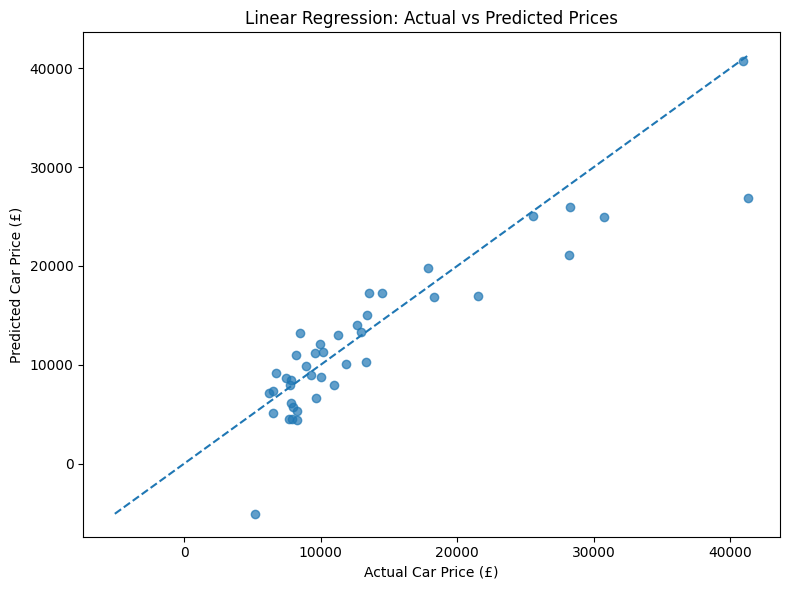

In [ ]:

# Plot actual prices against predicted prices
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Add a reference line for perfect predictions
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Car Price (dataset units)")
plt.ylabel("Predicted Car Price (dataset units)")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.tight_layout()
plt.show()



## Residual Analysis

Residual analysis is used to examine the differences between actual and predicted car prices. Residuals are calculated by subtracting predicted prices from actual prices. A residual plot helps identify patterns, systematic errors, and observations with large prediction errors.



**Key Findings:** Most predictions follow the general trend of actual car prices, with several points close to the perfect-prediction line. However, some higher-priced cars are substantially underpredicted, and one prediction is negative. These errors indicate that the Linear Regression model does not predict every vehicle's price accurately.


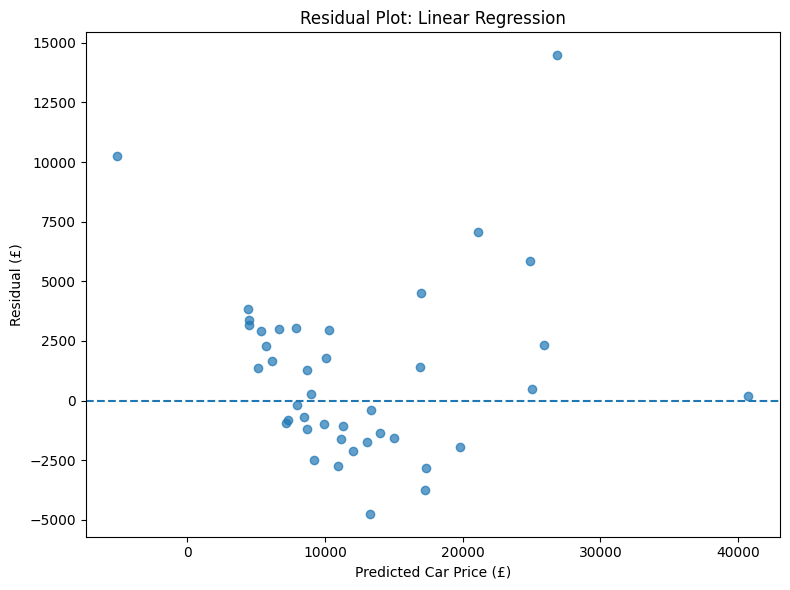

In [ ]:

# Calculate residuals
residuals = y_test - y_pred

# Plot residuals against predicted prices
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)

# Add a horizontal reference line at zero
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Car Price (dataset units)")
plt.ylabel("Residual (£)")
plt.title("Residual Plot: Linear Regression")
plt.tight_layout()
plt.show()



##  Comparing Regression Models

Linear Regression provides a baseline for predicting car prices. To determine whether a more flexible method improves predictive performance, it will be compared with Random Forest Regression using the same training and testing datasets. Both models will be evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and \(R^2\). Lower MAE and RMSE and higher \(R^2\) generally indicate better predictive performance.



**Key Findings:** Residuals are spread on both sides of the zero line, but several observations have large errors. The spread of residuals appears wider for higher predicted prices, suggesting that prediction errors may vary with car price. This indicates that Linear Regression does not capture all price patterns equally well and supports comparing it with a more flexible regression model.


In [ ]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Train a Random Forest regression model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_encoded, y_train)

# Generate predictions using both models
linear_pred = linear_model.predict(X_test_encoded)
rf_pred = rf_model.predict(X_test_encoded)

# Compare performance using the same test dataset
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regression"],
    "MAE": [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, rf_pred)
    ]
})

display(results.round(3))


,Model,MAE,RMSE,R2
0,Linear Regression,2702.390,3812.400,0.816
1,Random Forest Regression,1352.196,1885.513,0.955



**Key Findings:** Random Forest Regression outperformed Linear Regression across all three evaluation metrics. Its MAE decreased from £2,702.39 to £1,352.20, while RMSE decreased from £3,812.40 to £1,885.51. The \(R^2\) score increased from 0.816 to 0.955, indicating that Random Forest explained 95.5% of the variation in test-set car prices. These results suggest that Random Forest captures patterns in the data that the linear model may miss. Further validation is needed because the test set contains only 41 cars.



##  Random Forest: Actual vs Predicted Prices


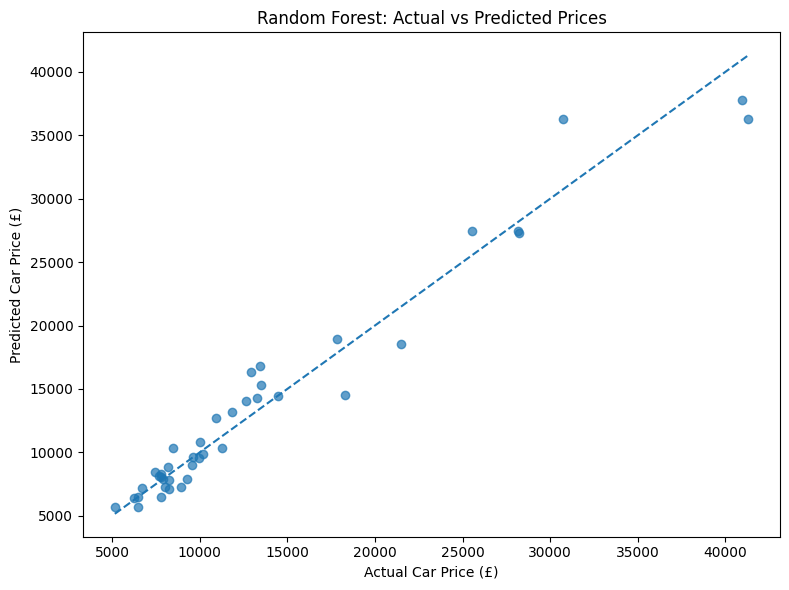

In [ ]:

# Plot actual prices against Random Forest predictions
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.7)

# Add a reference line for perfect predictions
min_price = min(y_test.min(), rf_pred.min())
max_price = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Car Price (dataset units)")
plt.ylabel("Predicted Car Price (dataset units)")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.tight_layout()
plt.show()



**Key Findings:** Most Random Forest predictions are close to the perfect-prediction line, consistent with the model's stronger evaluation scores. However, some higher-priced cars are overpredicted or underpredicted substantially. Random Forest improves overall predictive performance compared with Linear Regression, but some prediction errors remain.



## Visualising Model Performance

Bar charts will compare the performance of Linear Regression and Random Forest Regression using MAE, RMSE, and \(R^2\). This visual comparison will help identify which model produces more accurate predictions on the test dataset.


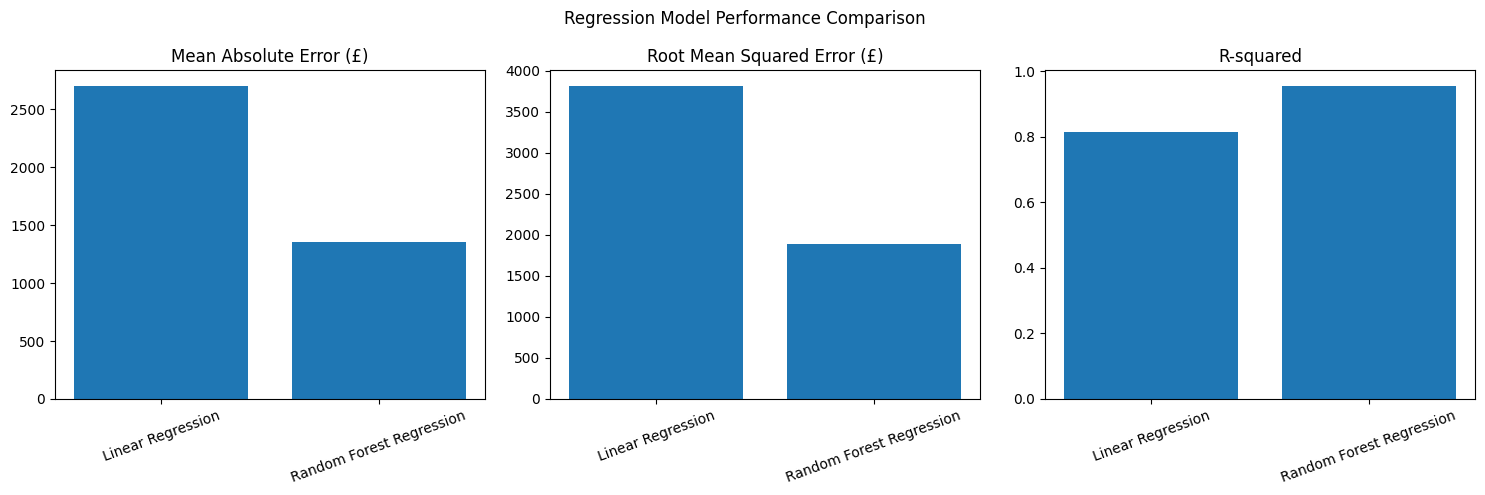

In [ ]:

# Plot model performance metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ("MAE", "Mean Absolute Error (£)"),
    ("RMSE", "Root Mean Squared Error (£)"),
    ("R2", "R-squared")
]

for ax, (metric, title) in zip(axes, metrics):
    ax.bar(results["Model"], results[metric])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Regression Model Performance Comparison")
plt.tight_layout()
plt.show()



**Key Findings:** The charts confirm that Random Forest Regression outperforms Linear Regression, with lower MAE (£1,352.20) and RMSE (£1,885.51), and a higher \(R^2\) score (0.955). Random Forest is therefore the stronger candidate for predicting car prices on this test set, although further validation is needed.



## Feature Importance Analysis

Feature importance will be examined to identify which vehicle characteristics contribute most to the Random Forest model's predictions. This analysis can help the business understand which factors are most useful for predicting car prices. Feature importance indicates predictive contribution, not causation.


,Feature,Importance
185,numerical__enginesize,0.584201
184,numerical__curbweight,0.260157
192,numerical__avg_mpg,0.049591
189,numerical__horsepower,0.022597
182,numerical__carwidth,0.014558
181,numerical__carlength,0.007191
191,numerical__power_to_weight,0.005266
190,numerical__peakrpm,0.005195
39,categorical__brand_bmw,0.005118
180,numerical__wheelbase,0.004433


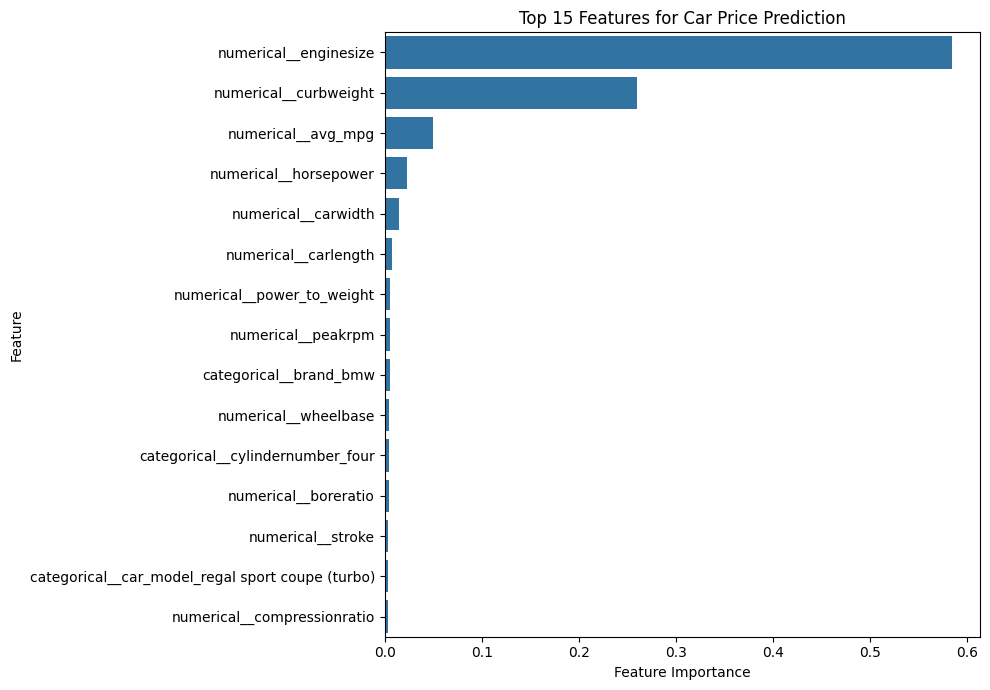

In [ ]:

# Get feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()

# Extract feature importance from the trained Random Forest model
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

# Sort features from most to least important
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display the 15 most important features
top_features = importance_df.head(15)

display(top_features)

# Visualise the most important features
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features for Car Price Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



**Key Findings:** Engine size is the most important feature in the Random Forest model, followed by curb weight. Average fuel economy and horsepower also contribute to predictions, while the remaining features have much smaller individual importance scores. These results suggest that engine and vehicle size characteristics are particularly useful for predicting car prices. Feature importance indicates predictive usefulness, not causation.



##  Final Conclusions and Business Recommendations

### Key Conclusions

The analysis identified relationships between car prices and vehicle characteristics. Exploratory data analysis showed strong correlations between price and features such as engine size, horsepower, and curb weight.

Linear Regression provided a baseline model, achieving an \(R^2\) score of 0.816 and an MAE of £2,702.39. Random Forest Regression performed better on the test set, achieving an \(R^2\) score of 0.955 and an MAE of £1,352.20. Feature importance analysis identified engine size and curb weight as the most influential predictors in the Random Forest model.

### Business Recommendations

- Consider engine size and curb weight when analysing vehicle pricing.
- Use Random Forest as the leading candidate for further price-prediction testing.
- Validate the model on additional data before using its predictions to guide real pricing decisions.

### Limitations

The dataset contains only 205 vehicles, and the test set contains 41 observations. The results may not generalise to other vehicle markets or newer models. Feature importance and correlations indicate associations, not causation. Further validation is needed before relying on the model for business decisions.


---


##  Reflection and Future Improvements

This project developed practical skills in data cleaning, exploratory data analysis, statistical testing, visualisation, and machine learning. Comparing Linear Regression with Random Forest demonstrated the importance of evaluating models rather than assuming one method will perform best.

Future improvements could include cross-validation, hyperparameter tuning, further feature selection, and testing the model on a larger and more representative dataset. These steps could improve the reliability and generalisability of price predictions.


---

In [ ]:

import plotly.express as px

# Create a simple interactive scatter plot
fig = px.scatter(
    df,
    x="enginesize",
    y="price",
    color="fueltype",
    hover_data=["horsepower", "curbweight"],
    title="Engine Size vs Car Price"
)
fig.show()